<a href="https://colab.research.google.com/github/rayyanmaan/would-i-instagram-this/blob/main/notebooks/iteration-1-pixel-statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Would I Instagram This?

### Iteration I — Predicting photo-sharing from pixel statistics

---

## 1. Dataset Description

### Motivation

I am someone who puts real thought into what I post on Instagram. Among my
friends, I have a reputation for understanding the art of curation, knowing
which photos are worth sharing and which belong in the camera roll forever.
This is not an accident. Before posting, I edit almost every photo: pulling
down exposure, nudging warmth, flattening saturation, and checking whether
the image has a certain compositional weight to it. There is no single
Instagram aesthetic, but there is a sensibility I try to meet, images that
feel intentional rather than accidental.

In concrete terms, the edits I reach for most are:

- **Exposure:** I prefer lower exposure over bright, blown-out images. Photos
  I post tend to be darker and moodier than straight-out-of-camera shots.
- **Warmth:** I lean warm, though not consistently. Some of my favorite posts
  are cooler and more desaturated.
- **Saturation:** I keep it restrained. Oversaturated photos feel cheap to me.
  I want color to be present but not aggressive.
- **Sharpness:** I want photos to be sharp, but not over-sharpened. Texture
  should feel natural.
- **Faces:** I rarely post selfies or close-up face photos. Most of what I
  share is environmental, compositional, or candid at a distance.

This project is a direct translation of those intuitions into a machine learning
problem. The features I extract are grounded in these exact editing decisions,
with additional features added to probe for patterns I might not be consciously
aware of.

### Research Question

Can low-level visual features capturing color, brightness, sharpness, and
composition predict whether a photo from my personal archive is likely to
be shared publicly on Instagram?

### Dataset

The dataset consists of personal photos drawn from my own digital archive,
manually organized into two categories prior to any modeling:

- **shared/** — photos I have posted or would post publicly on Instagram.
  Label: y = 1 (150 images)
- **personal/** — photos I keep private. Label: y = 0 (150 images)

This is a binary classification task. The labeling reflects my own subjective
judgment about shareability, making this a form of behavioral self-annotation.
The perfectly balanced class distribution (150 vs. 150) means accuracy is a
meaningful metric and no resampling is required.

**Data collection:** All images come from my personal photo library. No
external datasets were used. Labeling was performed manually before any
feature extraction or modeling, ensuring labels are not influenced by
the features we compute.

**Sampling rationale:** Photos were selected to represent a realistic range
of shooting conditions, different lighting, locations, subjects, and
compositions, rather than only clear-cut cases. This makes the task genuine.
A model trained on cherry-picked easy examples would not generalize to the
ambiguous real-world decisions that actually define my sharing behavior.

**Important caveat:** Labels reflect my aesthetic preferences at one point in
time, not universal standards of shareability. The model learned here is
intentionally idiosyncratic, it is a model of my behavior, not a theory
of what makes a photo objectively good.

The following code mounts Google Drive, sets directory paths, and loads
all image paths with their binary labels into Python lists for downstream
feature extraction.

In [ ]:
# ─── Core Imports ──────────────────────────────────────────────────────────────
import os
import glob
import copy
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import urllib.request
import warnings
import logging
from collections import Counter
from PIL import Image as PILImage

# Suppress verbose output
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.CRITICAL)

# ─── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_curve, auc, f1_score, precision_score,
    recall_score
)

# ─── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as tv_models

# ─── HuggingFace (BLIP, ViT, MiniLM) ───────────────────────────────────────────
from transformers import (
    BlipProcessor, BlipForConditionalGeneration,
    ViTImageProcessor, ViTForImageClassification
)
from sentence_transformers import SentenceTransformer

# ─── Colab: mount Google Drive ─────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ─── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Mounted at /content/drive
Device: cpu
PyTorch: 2.10.0+cpu


In [ ]:
# ─── Imports ───────────────────────────────────────────────────────────────────
import os
import glob
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import urllib.request

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, learning_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay,
                             roc_curve, auc, f1_score)

from google.colab import drive

# ─── Mount Drive ───────────────────────────────────────────────────────────────
drive.mount('/content/drive')

# ─── Paths ─────────────────────────────────────────────────────────────────────
SHARED_DIR   = '/content/drive/MyDrive/photos_for_ml/shared/'
PERSONAL_DIR = '/content/drive/MyDrive/photos_for_ml/personal/'

# ─── Load image paths and assign labels ────────────────────────────────────────
def load_image_paths(shared_dir, personal_dir):
    extensions = ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG')
    shared_paths, personal_paths = [], []
    for ext in extensions:
        shared_paths   += glob.glob(os.path.join(shared_dir, ext))
        personal_paths += glob.glob(os.path.join(personal_dir, ext))
    paths  = shared_paths + personal_paths
    labels = [1] * len(shared_paths) + [0] * len(personal_paths)
    print(f"Shared  (y=1): {len(shared_paths):>4} images")
    print(f"Personal(y=0): {len(personal_paths):>4} images")
    print(f"Total:         {len(paths):>4} images")
    return paths, labels

image_paths, labels = load_image_paths(SHARED_DIR, PERSONAL_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shared  (y=1):  150 images
Personal(y=0):  150 images
Total:          300 images


## 2. Feature Extraction

Rather than feeding raw pixel values into a classifier (which would produce
65,536 dimensions for a 256x256 image and require far more data to learn
from), we extract 13 hand-engineered scalar features per image. Each feature
is directly motivated by the editing decisions described in Section 1: the
controls I actually reach for when deciding whether a photo is post-worthy.

The feature set is organized into four conceptual groups:

**Color and Lighting** captures the aspects I most consciously edit. Mean
brightness maps to exposure. Saturation mean and variance capture color
intensity and consistency. Warmth (mean red minus mean blue) captures the
warm-cool tonal balance. Colorfulness uses the perceptual metric from Hasler
and Susstrunk (2003), which better approximates human color perception than
raw channel statistics by modeling the opponent color channels used by the
human visual system.

**Hue** features (mean and variance) capture the dominant color of the image
and how diverse the palette is. High hue variance suggests a colorful,
varied scene; low hue variance suggests a monochromatic or muted one.

**Sharpness and Texture** features probe technical quality. The Laplacian
variance method detects blur by measuring how much local intensity change
exists in the image, a sharp image has high second-derivative energy. Edge
density via Canny detection captures structural complexity, which relates to
how detailed and rich a scene appears.

**Composition and Subject** features capture where the visual energy sits
and whether a face is present. The center weight ratio compares brightness
in the central crop to the full image, approximating subject-foreground
prominence. The Haar cascade face detector provides a binary signal for
face presence and the relative size of the largest detected face.

The face features are included because I explicitly noted I rarely post
faces, so face presence should be a meaningful negative predictor of sharing.
The remaining features probe for patterns I may not be consciously controlling.

| # | Feature | Motivation |
|---|---------|------------|
| 1 | mean_brightness | Exposure control — I prefer lower exposure |
| 2 | brightness_var | Dynamic range — contrast and tonal depth |
| 3 | mean_saturation | Saturation level — I keep this restrained |
| 4 | saturation_var | Consistency of color across the image |
| 5 | warmth | Warm/cool tonal balance |
| 6 | colorfulness | Perceptual color richness (Hasler & Susstrunk 2003) |
| 7 | mean_hue | Dominant color temperature |
| 8 | hue_var | Palette diversity |
| 9 | sharpness | Laplacian variance — blur detection |
| 10 | edge_density | Canny edge fraction — structural complexity |
| 11 | center_weight | Subject prominence in composition |
| 12 | face_present | Binary face detection via Haar cascade |
| 13 | face_size_ratio | Relative area of largest detected face |

All features are scalar values. The extraction loop appends label
and filename columns alongside the 13 features, producing a working
DataFrame of shape (300, 15), from which the 13 feature columns are
selected by name for modeling.

In [ ]:
# ─── Haar Cascade for face detection ───────────────────────────────────────────
# Source: OpenCV's pre-trained frontal face detector, trained on the CBCL Face
# Database. Uses a cascade of Haar-like features (Viola & Jones, 2001).
# Reference: Viola, P. & Jones, M. (2001). Rapid object detection using a
# boosted cascade of simple features. CVPR 2001.
# Weights: https://github.com/opencv/opencv/tree/master/data/haarcascades

CASCADE_PATH = '/content/haarcascade_frontalface_default.xml'
if not os.path.exists(CASCADE_PATH):
    url = ('https://raw.githubusercontent.com/opencv/opencv/master/'
           'data/haarcascades/haarcascade_frontalface_default.xml')
    urllib.request.urlretrieve(url, CASCADE_PATH)
    print("Haar cascade downloaded.")
else:
    print("Haar cascade already present.")

face_cascade = cv2.CascadeClassifier(CASCADE_PATH)

# ─── Feature extraction ─────────────────────────────────────────────────────────
def extract_features(img_path, face_cascade, target_size=(256, 256)):
    """
    Extract 13 visual features from a single image.
    Returns a dict of floats, or None if the image cannot be loaded.
    All images are resized to target_size for consistency before extraction.
    """
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        return None

    img_bgr      = cv2.resize(img_bgr, target_size)
    img_rgb      = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_hsv      = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV).astype(np.float32)
    img_gray_u8  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)  # uint8 for OpenCV ops

    H = img_hsv[:, :, 0]
    S = img_hsv[:, :, 1]
    V = img_hsv[:, :, 2]
    R = img_rgb[:, :, 0].astype(float)
    G = img_rgb[:, :, 1].astype(float)
    B = img_rgb[:, :, 2].astype(float)

    # Color and Lighting
    mean_brightness = V.mean()
    brightness_var  = V.var()
    mean_saturation = S.mean()
    saturation_var  = S.var()
    warmth          = R.mean() - B.mean()

    # Colorfulness: Hasler & Susstrunk (2003) perceptual metric
    # Models the rg and yb opponent channels used by human color vision
    rg           = R - G
    yb           = 0.5 * (R + G) - B
    colorfulness = (np.sqrt(rg.std()**2 + yb.std()**2) +
                    0.3 * np.sqrt(rg.mean()**2 + yb.mean()**2))

    mean_hue = H.mean()
    hue_var  = H.var()

    # Sharpness: variance of Laplacian — measures second-derivative energy
    # High values = sharp edges present; low values = blurry image
    sharpness    = cv2.Laplacian(img_gray_u8, cv2.CV_64F).var()
    edges        = cv2.Canny(img_bgr, threshold1=50, threshold2=150)
    edge_density = edges.astype(bool).mean()

    # Composition: center brightness ratio
    h, w = V.shape
    mh, mw     = h // 4, w // 4
    center_crop = V[mh:h - mh, mw:w - mw]
    center_weight = center_crop.mean() / (mean_brightness + 1e-6)

    # Face detection via Haar cascade (Viola & Jones, 2001)
    faces       = face_cascade.detectMultiScale(
        img_gray_u8, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30)
    )
    face_present    = 1 if len(faces) > 0 else 0
    face_size_ratio = (max(wf * hf for (_, _, wf, hf) in faces) / (h * w)
                       if face_present else 0.0)

    return dict(
        mean_brightness=mean_brightness,
        brightness_var=brightness_var,
        mean_saturation=mean_saturation,
        saturation_var=saturation_var,
        warmth=warmth,
        colorfulness=colorfulness,
        mean_hue=mean_hue,
        hue_var=hue_var,
        sharpness=sharpness,
        edge_density=edge_density,
        center_weight=center_weight,
        face_present=face_present,
        face_size_ratio=face_size_ratio,
    )

# ─── Build DataFrame ────────────────────────────────────────────────────────────
records = []
for path, label in zip(image_paths, labels):
    feats = extract_features(path, face_cascade)
    if feats is not None:
        feats['label']    = label
        feats['filename'] = os.path.basename(path)
        records.append(feats)

df = pd.DataFrame(records)
print(f"\nFeature matrix shape: {df.shape}")
print(f"Class distribution:\n{df['label'].value_counts().to_string()}")
df.head()

Haar cascade downloaded.

Feature matrix shape: (300, 15)
Class distribution:
label
1    150
0    150


,mean_brightness,brightness_var,mean_saturation,saturation_var,warmth,colorfulness,mean_hue,hue_var,sharpness,edge_density,center_weight,face_present,face_size_ratio,label,filename
0,110.863770,2622.067627,76.540405,1641.161621,-32.033722,41.876212,86.191162,1126.975098,1196.182075,0.166061,1.138205,0,0.0,1,1EC99A9D-8718-4B71-85CC-B1CCD3C811E9_4_5005_c....
1,101.323318,2523.999023,74.197784,2463.022949,7.536224,32.019781,67.786957,1481.663452,1406.765186,0.221771,0.872875,0,0.0,1,F8390B5C-1EE7-40C6-B114-10D9E25BB6CE_4_5005_c....
2,53.280823,2360.830322,46.267029,1835.475098,9.977325,28.410070,39.123886,1135.322388,1935.363426,0.157120,1.130553,0,0.0,1,53474D5B-F5D9-4BF0-8FDB-9DE361C7B4E9_4_5005_c....
3,100.936996,1928.684326,26.518539,706.195984,0.545929,16.308628,48.669556,2034.310425,1634.142816,0.235931,1.004639,0,0.0,1,DA5A8B84-6592-4A42-841B-9163F281D641_4_5005_c....
4,81.661484,2110.895020,52.823898,1445.275391,9.414810,24.080185,31.598953,1222.996582,5728.935725,0.262405,1.148655,0,0.0,1,5502084B-A4BC-44BE-B6B4-D31A89AC529B_1_105_c.jpeg


## 3. Data Cleaning, Preprocessing and Exploratory Analysis

### Cleaning

No images failed to load, and all 13 features are deterministically computed
from valid pixel data, so no imputation was required. The dataset enters
modeling at full size: 300 images, 13 features, perfectly balanced classes.

### Preprocessing and the Case for Scaling

The 13 features span vastly different numerical ranges. Sharpness (Laplacian
variance) routinely reaches values in the thousands, while edge_density is
bounded strictly between 0 and 1, and face_size_ratio rarely exceeds 0.05.
If we feed these raw values to Logistic Regression, the gradient update for
sharpness would dominate numerically, not because sharpness is more important
but because its scale is larger. StandardScaler corrects this by transforming
each feature to zero mean and unit variance:

$$x'_j = \frac{x_j - \mu_j}{\sigma_j}$$

Critically, the scaler is fit only on the training set and then applied to
the test set. Fitting on the full dataset would leak test statistics into
training, producing an optimistic and misleading estimate of generalization.

Naive Bayes does not require scaling because it fits a Gaussian to each
feature independently, the scale of a feature does not affect how its
per-class distribution is estimated. We scale for LR only.

### Cross-Validation as the Validation Step

A standard ML pipeline uses three data splits: train, validation, and test.
The validation set is used during development to tune hyperparameters and
make modeling decisions without touching the test set. Here, we use
5-fold stratified cross-validation on the training set in place of a fixed
validation split. This is methodologically preferable: rather than committing
to one arbitrary 80/10/10 partition, we average over five different validation
folds, producing a lower-variance estimate of validation performance. The
test set (20% of the full dataset) remains held out until final evaluation.

### Exploratory Analysis

Before modeling, we examine the feature distributions and class-conditional
means to build intuition. The class-conditional means already reveal the
most striking finding in the dataset: personal photos are substantially
brighter on average (125.2) than shared photos (96.8). This directly
contradicts the common assumption that Instagram photos are bright and
saturated. The data suggests the opposite for my archive, and the modeling
results will need to explain why.

To quantify class separation beyond raw means, we compute Cohen's d for
each feature, a normalized measure of the difference between class
distributions that is independent of sample size:

$$d = \frac{\bar{x}_1 - \bar{x}_0}{s_p}$$

where $s_p$ is the pooled standard deviation:

$$s_p = \sqrt{\frac{(n_0 - 1)s_0^2 + (n_1 - 1)s_1^2}{n_0 + n_1 - 2}}$$

By convention, $|d| > 0.8$ is a large effect, $|d| > 0.5$ medium,
and $|d| > 0.2$ small (Cohen, 1988). This gives us a feature-level
measure of how well each individual feature could separate the classes
if used alone.

Cohen's d also connects to the Bayes-optimal error rate for a
single-feature Gaussian classifier. If both classes are Gaussian with
equal variance, the minimum achievable error using only feature $j$ is:

$$P_{\text{error}} = \Phi\!\left(-\frac{|d|}{2}\right)$$

where $\Phi$ is the standard normal CDF. For mean\_brightness with
$|d| = 0.959$, this gives $\Phi(-0.48) = 0.316$: even a theoretically
optimal single-feature classifier could not do better than 32% error
on brightness alone. The fact that our 13-feature LR achieves 20%
error confirms that combining features extracts information that no
single feature could provide independently.

=== Descriptive Statistics ===


,mean_brightness,brightness_var,mean_saturation,saturation_var,warmth,colorfulness,mean_hue,hue_var,sharpness,edge_density,center_weight,face_present,face_size_ratio
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,110.430000,3263.100000,68.700000,2038.410000,7.650000,31.670000,51.570000,1475.080000,2887.050000,0.170000,1.070000,0.120000,0.010000
std,32.780000,1351.870000,32.010000,1231.640000,24.270000,15.390000,25.170000,991.630000,2755.400000,0.070000,0.220000,0.320000,0.030000
min,31.000000,575.080000,11.880000,147.760000,-90.430000,4.290000,7.950000,11.140000,71.060000,0.020000,0.520000,0.000000,0.000000
25%,90.060000,2258.840000,45.590000,1037.100000,-2.990000,20.270000,32.080000,755.800000,1047.800000,0.110000,0.920000,0.000000,0.000000
50%,110.820000,3063.200000,64.380000,1809.520000,9.480000,29.330000,46.340000,1380.010000,1943.910000,0.160000,1.040000,0.000000,0.000000
75%,135.650000,4064.920000,87.270000,2779.470000,22.550000,40.690000,66.510000,1967.390000,3604.420000,0.220000,1.150000,0.000000,0.000000
max,184.360000,8846.330000,209.510000,5885.570000,99.570000,99.660000,131.130000,4928.130000,14711.520000,0.360000,2.060000,1.000000,0.230000



=== Class-Conditional Feature Means ===


,Personal,Shared
mean_brightness,124.820000,96.040001
brightness_var,3910.709961,2615.489990
mean_saturation,69.529999,67.870003
saturation_var,2240.729980,1836.089966
warmth,12.790000,2.510000
colorfulness,34.830000,28.510000
mean_hue,49.520000,53.610001
hue_var,1540.020020,1410.150024
sharpness,2967.280000,2806.830000
edge_density,0.160000,0.170000



=== Cohen's d — Feature Separability (Shared vs Personal) ===
(Positive = feature is higher in Shared photos)
(|d| > 0.8 = large effect, > 0.5 = medium, > 0.2 = small)


,Feature,Cohen's d,Direction,Effect Size
0,brightness_var,-1.090000,-,Large
1,mean_brightness,-0.976000,-,Large
2,warmth,-0.433000,-,Small
3,colorfulness,-0.419000,-,Small
4,saturation_var,-0.333000,-,Small
5,face_present,-0.229000,-,Small
6,face_size_ratio,-0.176000,-,Negligible
12,mean_hue,0.163000,+,Negligible
11,center_weight,0.145000,+,Negligible
7,hue_var,-0.131000,-,Negligible



Class balance: Shared=150, Personal=150, Ratio=1.00x


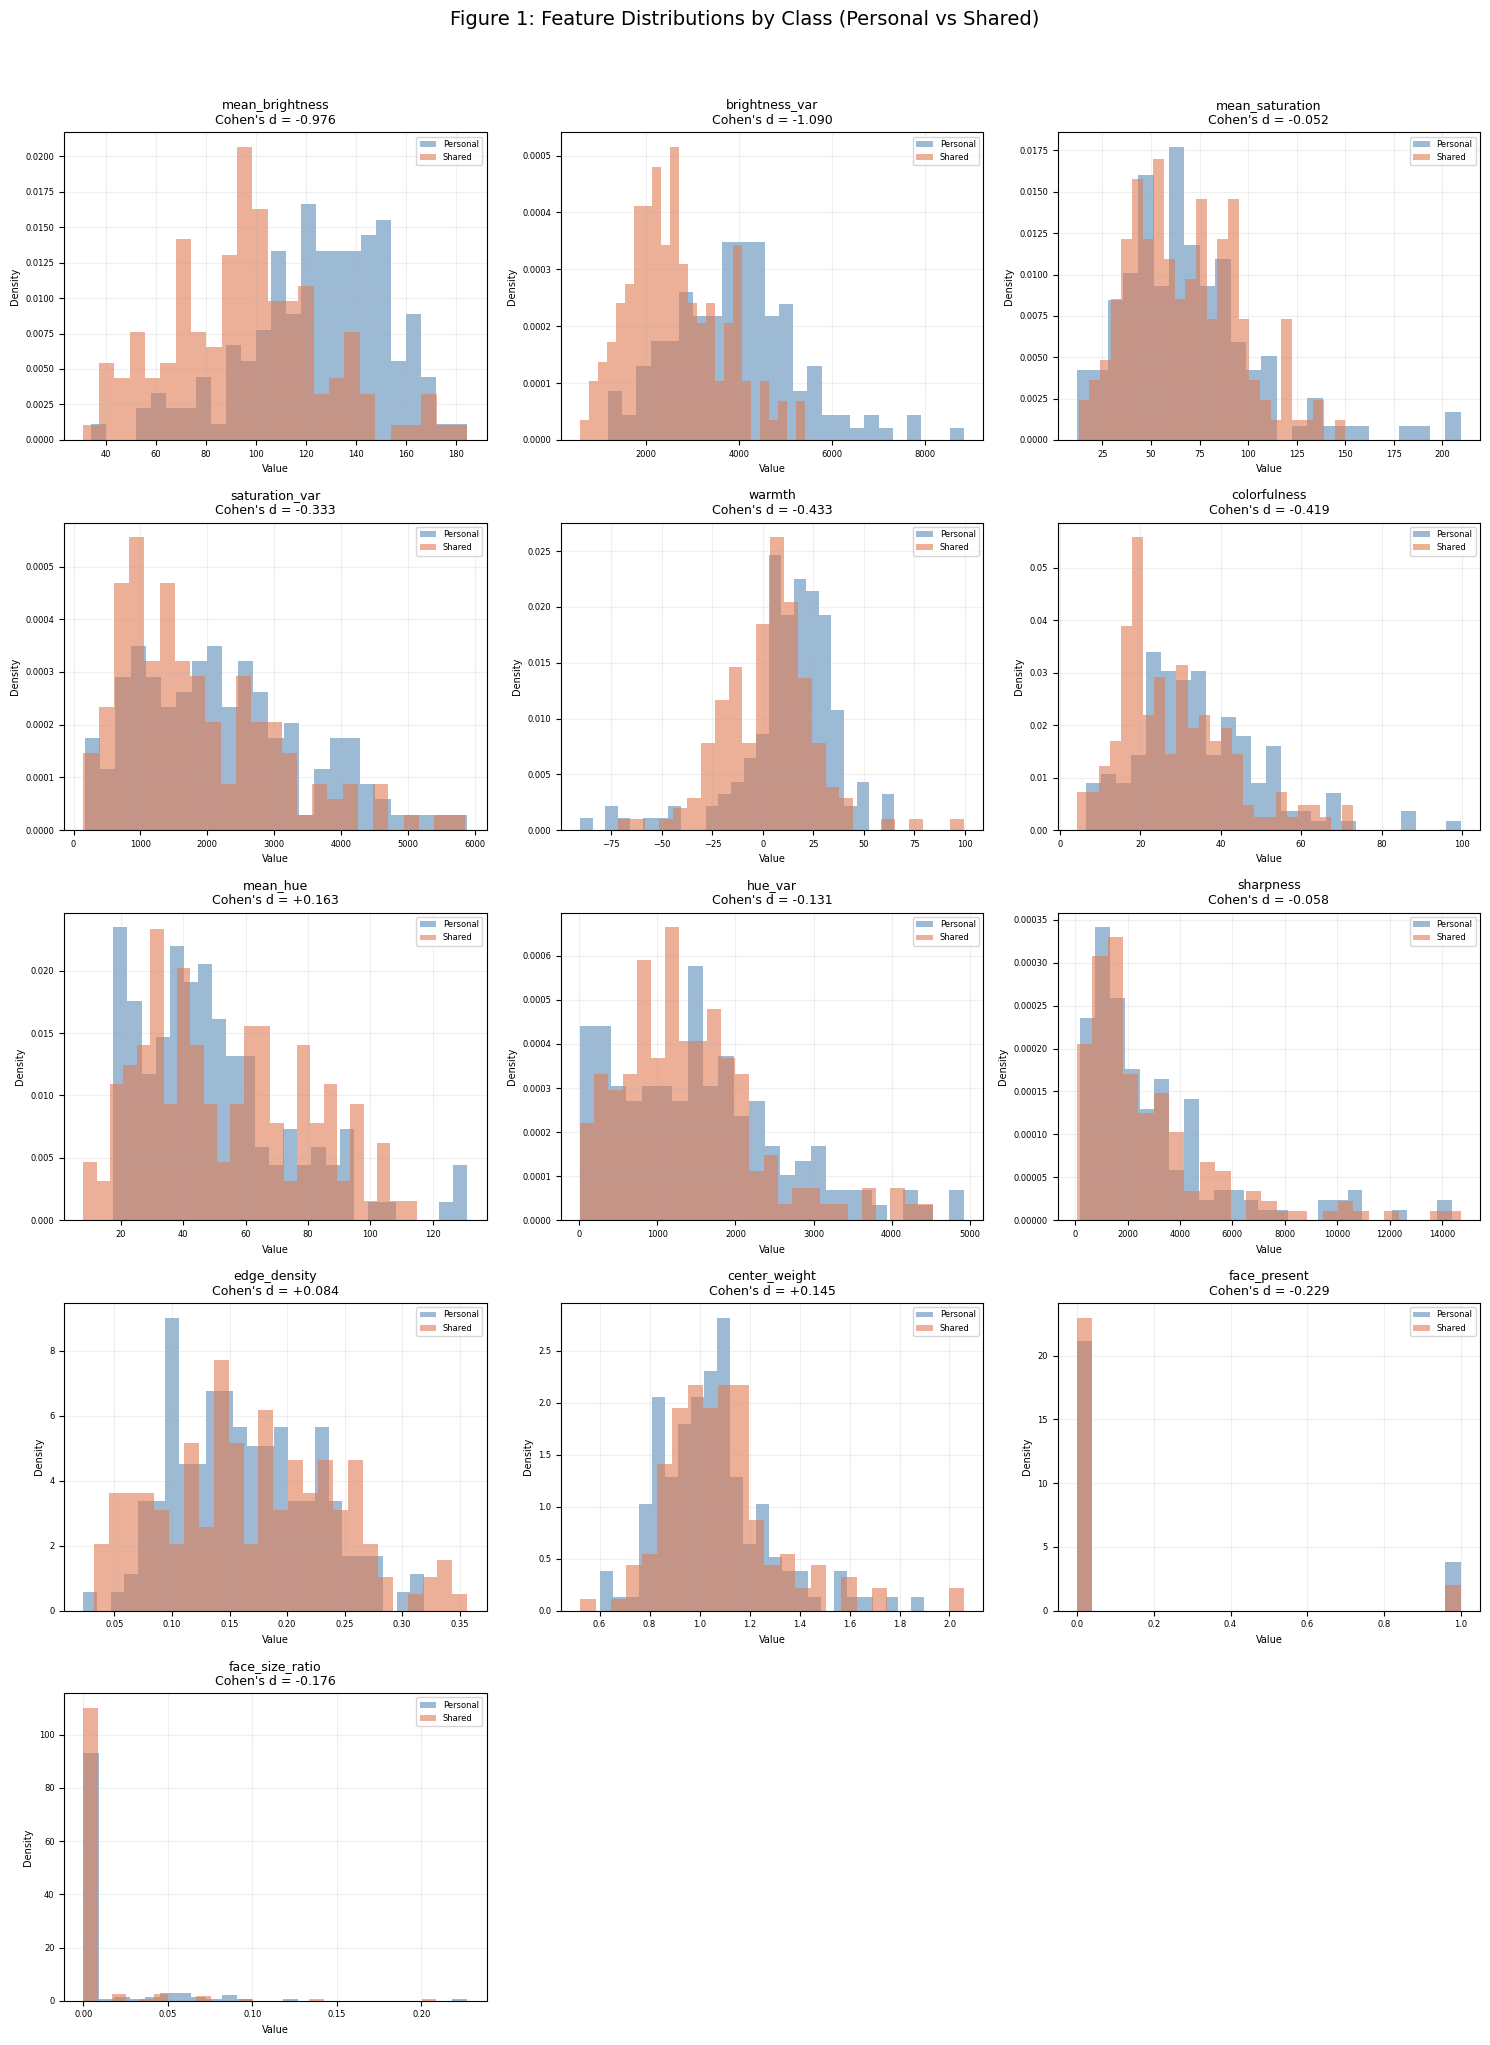

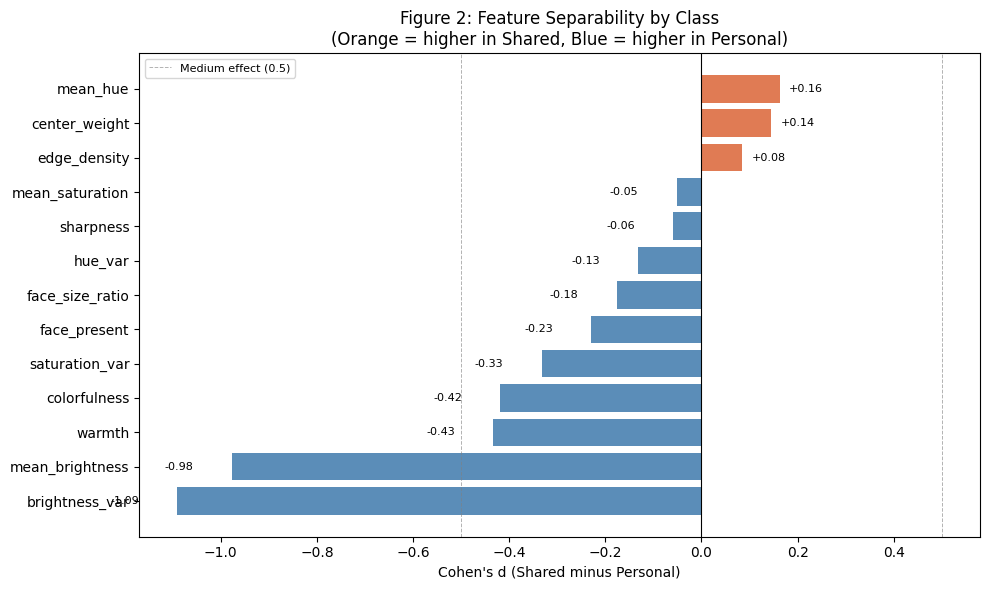

In [ ]:
feature_cols = [c for c in df.columns if c not in ('label', 'filename')]

# ─── Descriptive statistics (formatted as table) ────────────────────────────────
desc = df[feature_cols].describe().round(2)
print("=== Descriptive Statistics ===")
# Display as styled DataFrame in Colab
from IPython.display import display, HTML
display(desc.style.set_table_attributes('style="font-size: 12px"').set_caption("Feature Descriptives"))

print("\n=== Class-Conditional Feature Means ===")
class_means = df.groupby('label')[feature_cols].mean().round(2)
class_means.index = ['Personal (y=0)', 'Shared (y=1)']
# Transpose so features are rows, classes are columns (easier to read)
class_means_t = class_means.T
class_means_t.columns = ['Personal', 'Shared']
display(class_means_t.style.set_table_attributes('style="font-size: 12px"').set_caption("Mean Values by Class"))

# ─── Cohen's d: effect size per feature ────────────────────────────────────────
# Cohen's d = (mean_1 - mean_0) / pooled_std
# Measures class separability independent of sample size.
# |d| > 0.8 is considered a large effect (Cohen, 1988).
def cohens_d(group0, group1):
    n0, n1   = len(group0), len(group1)
    var0, var1 = group0.var(ddof=1), group1.var(ddof=1)
    pooled_std = np.sqrt(((n0 - 1) * var0 + (n1 - 1) * var1) / (n0 + n1 - 2))
    return (group1.mean() - group0.mean()) / (pooled_std + 1e-9)

g0 = df[df['label'] == 0]
g1 = df[df['label'] == 1]

d_values = {feat: cohens_d(g0[feat], g1[feat]) for feat in feature_cols}
d_series  = pd.Series(d_values).sort_values()

print("\n=== Cohen's d — Feature Separability (Shared vs Personal) ===")
print("(Positive = feature is higher in Shared photos)")
print("(|d| > 0.8 = large effect, > 0.5 = medium, > 0.2 = small)")

# Create a DataFrame for prettier output
d_table = pd.DataFrame({
    'Feature': d_series.index,
    "Cohen's d": d_series.values.round(3),
    'Direction': ['+' if d > 0 else '-' for d in d_series.values],
    '|d|': [abs(d) for d in d_series.values]
})
d_table['Effect Size'] = d_table['|d|'].apply(
    lambda x: 'Large' if x > 0.8 else ('Medium' if x > 0.5 else ('Small' if x > 0.2 else 'Negligible'))
)
# Drop the |d| column, keep only what we want to display
d_table_display = d_table[['Feature', "Cohen's d", 'Direction', 'Effect Size']].copy()
# Sort by absolute value for better readability
d_table_display = d_table_display.reindex(d_table_display["Cohen's d"].abs().sort_values(ascending=False).index)

# Display as styled table
display(d_table_display.style.set_table_attributes('style="font-size: 12px"')
        .set_caption("Feature Separability (Cohen's d)")
        .background_gradient(subset=["Cohen's d"], cmap='RdBu_r', vmin=-1, vmax=1))

# ─── Class balance ──────────────────────────────────────────────────────────────
counts = df['label'].value_counts()
print(f"\nClass balance: Shared={counts[1]}, Personal={counts[0]}, "
      f"Ratio={counts.max()/counts.min():.2f}x")

# ─── Figure 1: Separate histogram per feature ──────────────────────────────────
# Each subplot shows the class-conditional density for one feature.
# Cohen's d is annotated on each panel for reference.
# EDITED: Now displays in a 3-column grid layout

n_features = len(feature_cols)
colors     = {'Personal': '#5B8DB8', 'Shared': '#E07B54'}

# Calculate grid dimensions: 3 columns, rows as needed
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

# Create figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
fig.suptitle('Figure 1: Feature Distributions by Class (Personal vs Shared)', fontsize=14, y=1.02)

# Flatten axes for easy indexing
if n_rows > 1 or n_cols > 1:
    axes_flat = axes.flatten()
else:
    axes_flat = [axes]

# Plot each feature
for i, feat in enumerate(feature_cols):
    ax = axes_flat[i]
    for cls, label_name, color in [(0, 'Personal', '#5B8DB8'),
                                    (1, 'Shared',   '#E07B54')]:
        subset = df[df['label'] == cls][feat]
        ax.hist(subset, bins=25, alpha=0.6, color=color,
                label=label_name, density=True)
    d_val = d_values[feat]
    ax.set_title(f'{feat}\nCohen\'s d = {d_val:+.3f}', fontsize=9)
    ax.set_xlabel('Value', fontsize=7)
    ax.set_ylabel('Density', fontsize=7)
    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.2)
    ax.tick_params(labelsize=6)

# Hide any unused subplots
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig('fig1_all_features_grid.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── Figure 2: Cohen's d summary bar chart ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))  # Slightly larger for better readability
bar_colors = ['#E07B54' if d > 0 else '#5B8DB8' for d in d_series.values]
bars = ax.barh(d_series.index, d_series.values, color=bar_colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline( 0.5, color='gray', linewidth=0.7, linestyle='--', alpha=0.6,
            label='Medium effect (0.5)')
ax.axvline(-0.5, color='gray', linewidth=0.7, linestyle='--', alpha=0.6)
ax.set_xlabel("Cohen's d (Shared minus Personal)")
ax.set_title("Figure 2: Feature Separability by Class\n"
             "(Orange = higher in Shared, Blue = higher in Personal)")
ax.legend(fontsize=8)

# Add value labels on bars
for i, (bar, d) in enumerate(zip(bars, d_series.values)):
    width = bar.get_width()
    label_x = width + 0.02 if width > 0 else width - 0.08
    ax.text(label_x, bar.get_y() + bar.get_height()/2,
            f'{d:+.2f}', va='center', ha='left' if width > 0 else 'right',
            fontsize=8)

plt.tight_layout()
plt.savefig('fig2_cohens_d.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Analysis Design and Train/Test Split

### Task Definition

We treat this as a supervised binary classification problem: given the 13
visual features of an image, predict y in {0, 1} where 1 means shared and
0 means personal.

The choice of binary classification is natural: labels are discrete and
mutually exclusive (share or do not share), ground-truth annotations exist
for every image, and the 50/50 class balance means no resampling is needed.

### Split Strategy

We use a stratified 80/20 train/test split, yielding 240 training images
and 60 test images with equal class representation in each split. Stratified
sampling ensures the 50/50 class balance is preserved exactly in both
the training and test sets.

The 5-fold stratified cross-validation on the training set serves as the
validation stage. Rather than a fixed 80/10/10 train/validation/test
partition, we average across 5 folds, each time holding out a different
fifth of the training data. This produces a lower-variance estimate of
validation performance and makes better use of the available data.
The test set is not touched until Section 7.

### Why Not a Fixed Validation Set?

With 240 training images, a fixed 10% validation set would give us only
24 images to estimate performance, not enough to distinguish meaningful
differences from noise. Five-fold CV gives us 48 validation images per fold
and five independent estimates, averaging across their variance. This is
the standard practice in small-to-medium dataset regimes.

In [ ]:
X = df[feature_cols].values.astype(np.float64)
y = df['label'].values

# ─── Stratified 80/20 split ────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("=" * 60)
print("DATA SPLIT SUMMARY")
print("=" * 60)
print(f"{'Training set:':<20} {X_train.shape[0]:3d} images  "
      f"(Class 0: {np.bincount(y_train)[0]:3d}, Class 1: {np.bincount(y_train)[1]:3d})")
print(f"{'Test set:':<20} {X_test.shape[0]:3d} images  "
      f"(Class 0: {np.bincount(y_test)[0]:3d}, Class 1: {np.bincount(y_test)[1]:3d})")

# ─── Class distribution percentages ─────────────────────────────────────────────
train_pct0 = 100 * np.bincount(y_train)[0] / len(y_train)
train_pct1 = 100 * np.bincount(y_train)[1] / len(y_train)
test_pct0 = 100 * np.bincount(y_test)[0] / len(y_test)
test_pct1 = 100 * np.bincount(y_test)[1] / len(y_test)

print(f"\n{'Training distribution:':<20} Class 0: {train_pct0:.1f}%, Class 1: {train_pct1:.1f}%")
print(f"{'Test distribution:':<20} Class 0: {test_pct0:.1f}%, Class 1: {test_pct1:.1f}%")

# ─── Scale features ─────────────────────────────────────────────────────────────
# Fit scaler on training data ONLY. Applying it to test data uses train
# statistics, preventing any leakage of test information into training.
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\n" + "=" * 60)
print("SCALING VERIFICATION")
print("=" * 60)
print("Post-scaling training feature means (should be ~0):")
print("Post-scaling train feature stds  (should be ~1):")
print("=" * 60)

# Create a DataFrame for nicer display of scaling verification
scaling_check = pd.DataFrame({
    'Feature': feature_cols,
    'Mean (post-scale)': X_train_scaled.mean(axis=0).round(3),
    'Std (post-scale)': X_train_scaled.std(axis=0).round(3)
})
print(scaling_check.to_string(index=False))

DATA SPLIT SUMMARY
Training set:        240 images  (Class 0: 120, Class 1: 120)
Test set:             60 images  (Class 0:  30, Class 1:  30)

Training distribution: Class 0: 50.0%, Class 1: 50.0%
Test distribution:   Class 0: 50.0%, Class 1: 50.0%

SCALING VERIFICATION
Post-scaling training feature means (should be ~0):
Post-scaling train feature stds  (should be ~1):
        Feature  Mean (post-scale)  Std (post-scale)
mean_brightness                0.0               1.0
 brightness_var                0.0               1.0
mean_saturation                0.0               1.0
 saturation_var                0.0               1.0
         warmth                0.0               1.0
   colorfulness               -0.0               1.0
       mean_hue                0.0               1.0
        hue_var                0.0               1.0
      sharpness               -0.0               1.0
   edge_density               -0.0               1.0
  center_weight               -0.0          

## 5. Model Selection and Mathematical Background

We train three classifiers: a Logistic Regression (primary model, via sklearn),
a Gaussian Naive Bayes (probabilistic baseline), and a Logistic Regression
implemented from scratch in NumPy to expose the mechanics of the optimization.

---

### Primary Model: Logistic Regression

Logistic Regression is a discriminative linear classifier. It directly models
the posterior probability of the class label given the feature vector, without
making any assumptions about how the features themselves are distributed:

$$P(y = 1 \mid \mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b)$$

where the sigmoid function maps any real value to the range (0, 1):

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

The sigmoid is the natural choice here because it enforces a valid probability
output and has a gradient that is clean to work with. As z grows large,
sigma(z) approaches 1 (predict shared); as z becomes very negative, sigma(z)
approaches 0 (predict personal).

**Training** minimizes binary cross-entropy loss over the training set:

$$\mathcal{L}(\mathbf{w}) = -\frac{1}{n} \sum_{i=1}^{n}
\left[ y_i \log \hat{p}_i + (1 - y_i) \log(1 - \hat{p}_i) \right]$$

This loss penalizes confident wrong predictions much more severely than
uncertain ones. If the model assigns probability 0.99 to "shared" but the
true label is "personal," the loss contribution is -log(0.01) = 4.6, which
is large. This asymmetric penalty drives the model toward calibrated
confidence.

**L2 Regularization** adds a penalty term to the loss:

$$\mathcal{L}_{\text{reg}}(\mathbf{w}) = \mathcal{L}(\mathbf{w}) +
\frac{1}{2C} \|\mathbf{w}\|^2$$

where C controls regularization strength (lower C = stronger penalty).
With C = 1.0, the penalty shrinks large coefficients toward zero, reducing
the risk of overfitting to noise in the training data.

**Gradient** of the cross-entropy loss with respect to the weights:

$$\nabla_{\mathbf{w}} \mathcal{L} = \frac{1}{n} \mathbf{X}^\top
(\hat{\mathbf{p}} - \mathbf{y})$$

This gradient has a clean interpretation: it is the average residual error
(prediction minus label) projected back through the feature matrix.

**Interpretability:** After training, each learned weight $w_j$ reflects
feature $j$'s contribution to the log-odds of sharing:

$$\log \frac{P(y=1 \mid \mathbf{x})}{P(y=0 \mid \mathbf{x})} =
\mathbf{w}^\top \mathbf{x} + b$$

A large positive $w_j$ means a one-standard-deviation increase in feature $j$
increases the log-odds of sharing by $w_j$.

---

### Baseline Model: Gaussian Naive Bayes

Naive Bayes is a generative classifier. Rather than directly modeling
P(y | x), it models the joint distribution P(x, y) = P(y) * P(x | y)
and applies Bayes' theorem to recover the posterior:

$$P(y \mid \mathbf{x}) = \frac{P(y) \prod_{j=1}^{d} P(x_j \mid y)}{P(\mathbf{x})}$$

The "naive" assumption is conditional independence: given the class label,
features are treated as independent of one another:

$$P(\mathbf{x} \mid y) = \prod_{j=1}^{d} P(x_j \mid y)$$

For Gaussian NB, each conditional is modeled as a Gaussian fitted to the
training data for that class:

$$P(x_j \mid y = c) = \frac{1}{\sqrt{2\pi\sigma_{jc}^2}}
\exp\!\left( -\frac{(x_j - \mu_{jc})^2}{2\sigma_{jc}^2} \right)$$

where $\mu_{jc}$ and $\sigma_{jc}^2$ are the class-conditional mean and
variance of feature $j$, estimated directly from the training set.

**Why this assumption is likely violated here:** Several of our features are
physically correlated. Brightness and saturation co-vary with lighting
conditions. Sharpness and edge density both measure spatial frequency content.
When NB treats these as independent, it double-counts their evidence at the
decision boundary, leading to miscalibrated probabilities and worse performance
than LR. The correlation heatmap in Section 8 quantifies this directly.

---

### From-Scratch Logistic Regression: Pseudocode

The following pseudocode makes the gradient descent procedure explicit:
```
Algorithm: Logistic Regression via Batch Gradient Descent
Input:  X_train (n x d), y_train (n,), learning rate eta, iterations T
Output: weights w (d,), bias b

Initialize: w <- 0^d,  b <- 0,  losses <- []

For t = 1 to T:
    z <- X_train @ w + b              # linear combination  (n,)
    p <- 1 / (1 + exp(-z))            # sigmoid activation  (n,)
    error <- p - y_train              # residual vector     (n,)
    grad_w <- (X_train^T @ error) / n # weight gradient     (d,)
    grad_b <- mean(error)              # bias gradient       scalar
    w <- w - eta * grad_w             # weight update
    b <- b - eta * grad_b             # bias update
    loss <- -mean(y*log(p) + (1-y)*log(1-p))
    losses.append(loss)

Return w, b, losses
```

We run this for 1000 iterations at learning rate 0.1. The
convergence behavior and accuracy verification are shown in
Section 6.

---

### Why These Two Models?

Logistic Regression and Naive Bayes represent two fundamentally different
philosophies. LR is discriminative: it learns a decision boundary directly
from labeled examples, asking "what linear combination of features separates
the classes?" NB is generative: it builds a probabilistic model of how each
class produces features, asking "given this class, how likely is this feature
vector?" The comparison is informative because our features are correlated,
and NB's independence assumption is therefore violated in a way we can measure.
If the performance gap is large, it tells us that feature correlations are
load-bearing in this classification problem.

In [ ]:
# ─── sklearn Logistic Regression ───────────────────────────────────────────────
lr_model = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

# ─── Gaussian Naive Bayes ──────────────────────────────────────────────────────
nb_model = GaussianNB()

# ─── From-scratch Logistic Regression ──────────────────────────────────────────
class LogisticRegressionScratch:
    """
    Binary Logistic Regression trained via batch gradient descent.
    Implements exactly the pseudocode in Section 5.
    Uses only NumPy — no sklearn in the optimization loop.
    """
    def __init__(self, lr=0.1, n_iter=1000):
        self.lr, self.n_iter = lr, n_iter
        self.losses = []

    @staticmethod
    def sigmoid(z):
        # Clip to prevent exp overflow on extreme values
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, X, y):
        n, d     = X.shape
        self.w   = np.zeros(d)
        self.b   = 0.0
        for _ in range(self.n_iter):
            z        = X @ self.w + self.b
            p        = self.sigmoid(z)
            error    = p - y
            self.w  -= self.lr * (X.T @ error) / n
            self.b  -= self.lr * error.mean()
            loss     = -np.mean(y * np.log(p + 1e-15) +
                                (1 - y) * np.log(1 - p + 1e-15))
            self.losses.append(loss)
        return self

    def predict_proba(self, X):
        return self.sigmoid(X @ self.w + self.b)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

lr_scratch = LogisticRegressionScratch(lr=0.1, n_iter=1000)

print("Models initialized:")
print("  sklearn LogisticRegression  (C=1.0, l2, lbfgs)")
print("  GaussianNB")
print("  LogisticRegressionScratch   (lr=0.1, n_iter=1000, NumPy only)")

Models initialized:
  sklearn LogisticRegression  (C=1.0, l2, lbfgs)
  GaussianNB
  LogisticRegressionScratch   (lr=0.1, n_iter=1000, NumPy only)


## 6. Model Training and Cross-Validation

All three classifiers are trained on the StandardScaler-normalized 240-image training set.

### Cross-Validation Strategy

We use 5-fold stratified cross-validation on the training data. In each fold,
192 images are used for training and 48 for validation, with class proportions
preserved via stratification. This gives 5 independent accuracy estimates per
model. The mean accuracy across folds is our best estimate of generalization
performance before the test set is revealed.

The standard deviation across folds is equally important: a high standard
deviation suggests the model is sensitive to which particular 192 images it
sees, which would be a sign of instability on this dataset size.

### Gradient Descent Convergence

For the from-scratch model, we plot the binary cross-entropy loss at each
of the 1000 gradient descent iterations. Convergence, the loss flattening
to a stable value, confirms that the learning rate (0.1) and iteration
count (1000) are appropriate. If the loss were still decreasing at iteration
1000, we would need to run longer. If it oscillated or diverged, the learning
rate would be too high.

The exact match between sklearn LR and our scratch implementation on training
accuracy is the definitive check that the from-scratch code correctly
implements the same objective function.

=== 5-Fold Cross-Validation (training set only) ===
Logistic Regression : 0.775 +/- 0.031
  Fold scores: [0.75  0.75  0.771 0.833 0.771]
Naive Bayes         : 0.708 +/- 0.083
  Fold scores: [0.771 0.646 0.812 0.729 0.583]

Train accuracy — sklearn LR : 0.808
Train accuracy — scratch LR : 0.808
Implementations agree exactly.


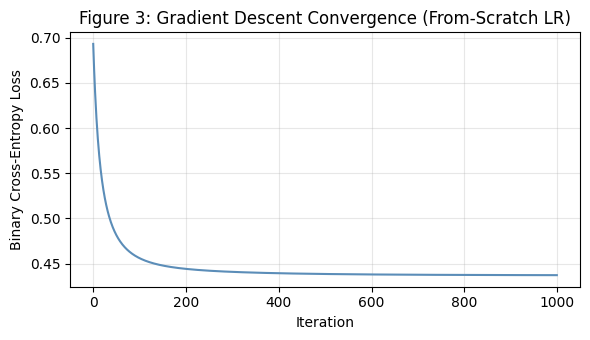

In [ ]:
# ─── Train all models ──────────────────────────────────────────────────────────
lr_model.fit(X_train_scaled, y_train)
nb_model.fit(X_train_scaled, y_train)
lr_scratch.fit(X_train_scaled, y_train)

# ─── 5-fold stratified cross-validation ───────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_lr = cross_val_score(lr_model, X_train_scaled, y_train,
                        cv=cv, scoring='accuracy')
cv_nb = cross_val_score(nb_model, X_train_scaled, y_train,
                        cv=cv, scoring='accuracy')

print("=== 5-Fold Cross-Validation (training set only) ===")
print(f"Logistic Regression : {cv_lr.mean():.3f} +/- {cv_lr.std():.3f}")
print(f"  Fold scores: {np.round(cv_lr, 3)}")
print(f"Naive Bayes         : {cv_nb.mean():.3f} +/- {cv_nb.std():.3f}")
print(f"  Fold scores: {np.round(cv_nb, 3)}")

# ─── Train accuracy comparison (sklearn vs scratch) ────────────────────────────
sklearn_train = accuracy_score(y_train, lr_model.predict(X_train_scaled))
scratch_train = accuracy_score(y_train, lr_scratch.predict(X_train_scaled))
print(f"\nTrain accuracy — sklearn LR : {sklearn_train:.3f}")
print(f"Train accuracy — scratch LR : {scratch_train:.3f}")
if sklearn_train == scratch_train:
    print("Implementations agree exactly.")

# ─── Figure 3: Gradient descent loss curve ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(lr_scratch.losses, color='#5B8DB8', linewidth=1.5)
ax.set_xlabel('Iteration')
ax.set_ylabel('Binary Cross-Entropy Loss')
ax.set_title('Figure 3: Gradient Descent Convergence (From-Scratch LR)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig3_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Out-of-Sample Predictions and Performance Metrics

We now evaluate all three classifiers on the 60-image test set: data that
has not been seen during training or cross-validation at any point.

### Metrics

- **Accuracy** is the fraction of correct predictions. It is interpretable
here because our classes are perfectly balanced (30 personal, 30 shared in
the test set), so a naive majority-class baseline would achieve only 50%.
- **Precision** for class c: of all images predicted as c, what fraction
actually belong to c? High precision means few false positives.
- **Recall** for class c: of all images that truly belong to c, what fraction
did the model correctly identify? High recall means few false negatives.
- **F1 Score** is the harmonic mean of precision and recall. It penalizes
models that sacrifice one for the other and is a cleaner single-number
summary than accuracy when we care about both error types.
- **Confusion matrix** shows the full 2x2 breakdown of predictions versus
true labels, making it easy to see whether the model errs more often in
one direction than the other.
- **ROC Curve and AUC** plot the true positive rate against the false positive
rate across all possible classification thresholds, not just the default
0.5 cutoff. AUC (area under the ROC curve) ranges from 0.5 (random) to
1.0 (perfect) and is threshold-independent, making it the most complete
single summary of binary classifier performance.

,Model,Accuracy,F1-Score (Macro),AUC
0,Logistic Regression,0.783,0.783,0.837
1,Naive Bayes,0.650,0.648,0.776
2,LR (from scratch),0.767,0.766,0.837


,precision,recall,f1-score,support
Personal,0.774000,0.800000,0.787000,30
Shared,0.793000,0.767000,0.780000,30
macro avg,0.784000,0.783000,0.783000,60
weighted avg,0.784000,0.783000,0.783000,60


--------------------------------------------------


,precision,recall,f1-score,support
Personal,0.680000,0.567000,0.618000,30
Shared,0.629000,0.733000,0.677000,30
macro avg,0.654000,0.650000,0.648000,60
weighted avg,0.654000,0.650000,0.648000,60


--------------------------------------------------


,precision,recall,f1-score,support
Personal,0.750000,0.800000,0.774000,30
Shared,0.786000,0.733000,0.759000,30
macro avg,0.768000,0.767000,0.766000,60
weighted avg,0.768000,0.767000,0.766000,60


--------------------------------------------------


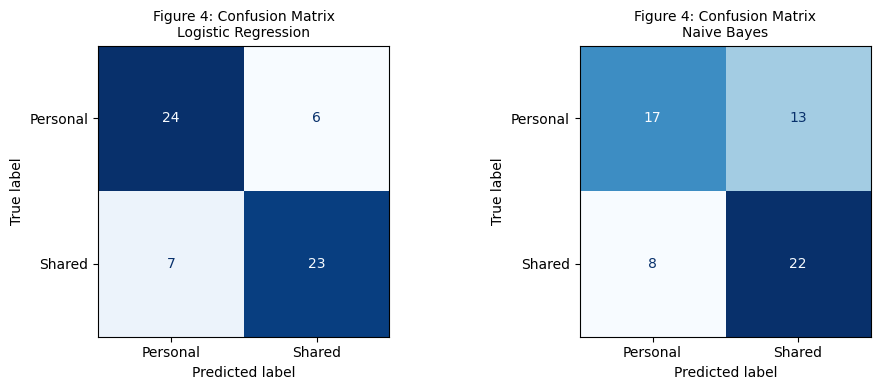

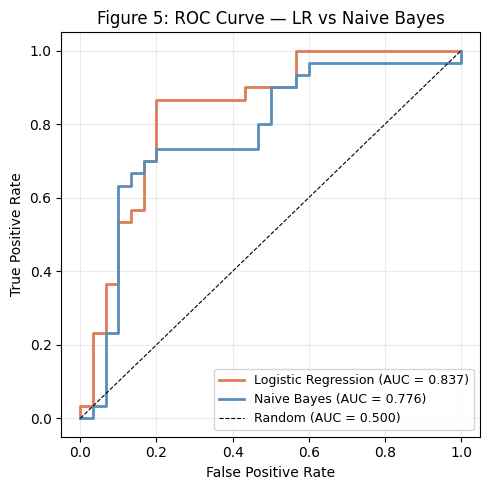

In [ ]:
# ─── Predictions ───────────────────────────────────────────────────────────────
y_pred_lr     = lr_model.predict(X_test_scaled)
y_pred_nb     = nb_model.predict(X_test_scaled)
y_pred_scratch = lr_scratch.predict(X_test_scaled)

y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
y_prob_nb = nb_model.predict_proba(X_test_scaled)[:, 1]

# ─── Performance summary table ────────────────────────────────────────────────────
# Create performance DataFrame
perf_data = []
for name, preds, probs in [
        ('Logistic Regression',  y_pred_lr,     y_prob_lr),
        ('Naive Bayes',          y_pred_nb,     y_prob_nb),
        ('LR (from scratch)',    y_pred_scratch, y_prob_lr)]:
    acc  = accuracy_score(y_test, preds)
    f1   = f1_score(y_test, preds, average='macro')
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = auc(fpr, tpr)
    perf_data.append({
        'Model': name,
        'Accuracy': round(acc, 3),
        'F1-Score (Macro)': round(f1, 3),
        'AUC': round(auc_val, 3)
    })

perf_df = pd.DataFrame(perf_data)
from IPython.display import display
display(perf_df.style.set_table_attributes('style="font-size: 12px"')
        .set_caption('Model Performance Summary')
        .format({'Accuracy': '{:.3f}', 'F1-Score (Macro)': '{:.3f}', 'AUC': '{:.3f}'}))


# ─── Detailed classification reports as tables ─────────────────────────────────
for name, preds in [('Logistic Regression', y_pred_lr),
                    ('Naive Bayes',          y_pred_nb),
                    ('LR (from scratch)',    y_pred_scratch)]:

    # Get classification report as dict
    report = classification_report(y_test, preds,
                                   target_names=['Personal', 'Shared'],
                                   output_dict=True)

    # Convert to DataFrame for nice display
    report_df = pd.DataFrame(report).transpose()

    # Round numeric columns
    for col in ['precision', 'recall', 'f1-score']:
        if col in report_df.columns:
            report_df[col] = report_df[col].round(3)

    # Display only the rows we want
    display_df = report_df.loc[['Personal', 'Shared', 'macro avg', 'weighted avg']]

    # Format the display
    from IPython.display import display
    display(display_df.style.set_table_attributes('style="font-size: 12px"')
            .set_caption(f'Classification Report - {name}')
            .format({'support': '{:.0f}'}))

    print("-" * 50)

# ─── Figure 4: Confusion matrices ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, preds) in zip(axes,
        [('Logistic Regression', y_pred_lr),
         ('Naive Bayes',         y_pred_nb)]):
    cm   = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Personal', 'Shared'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Figure 4: Confusion Matrix\n{name}', fontsize=10)
plt.tight_layout()
plt.savefig('fig4_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── Figure 5: ROC curves ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))
for name, probs, color in [('Logistic Regression', y_prob_lr, '#E07B54'),
                             ('Naive Bayes',         y_prob_nb, '#5B8DB8')]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC = {auc_val:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Figure 5: ROC Curve — LR vs Naive Bayes')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('fig5_roc.png', dpi=150, bbox_inches='tight')
plt.show()

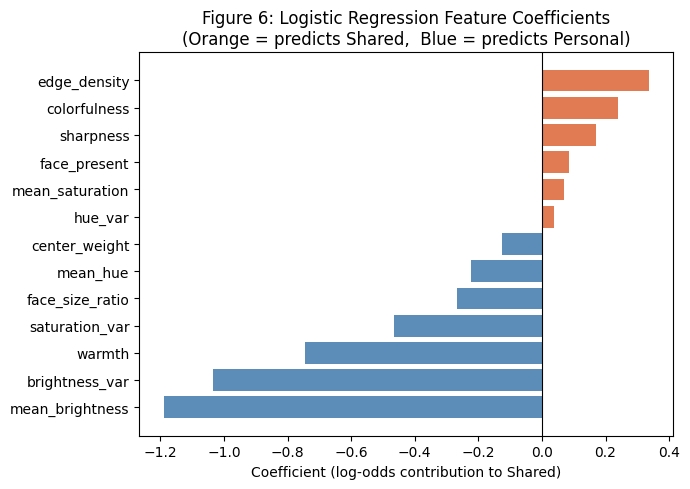

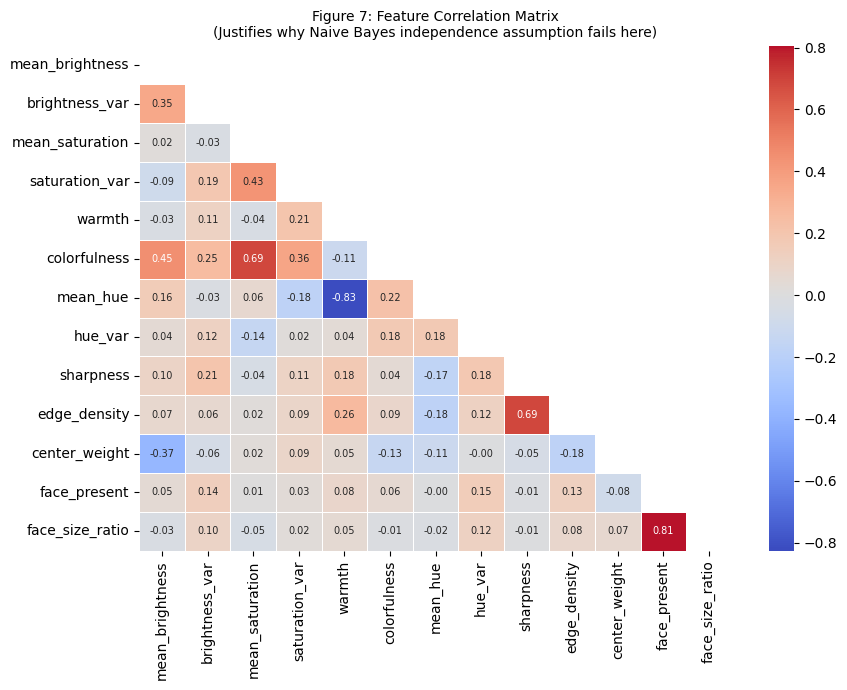

Feature pairs with |r| > 0.4:
             f1              f2         r
face_size_ratio    face_present  0.806359
   colorfulness mean_saturation  0.689512
   edge_density       sharpness  0.687495
   colorfulness mean_brightness  0.452665
 saturation_var mean_saturation  0.433908
       mean_hue          warmth -0.825941


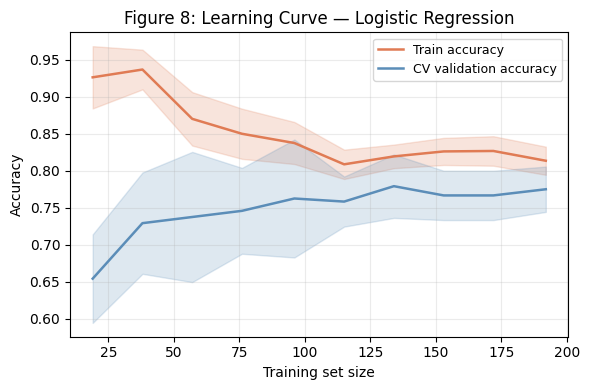


PCA Variance Explained:
  PC1: 18.2%
  PC2: 17.1%
  Total (2 components): 35.3%
LR accuracy in 2D PCA space: 0.717 (vs 0.783 in full 13D space)


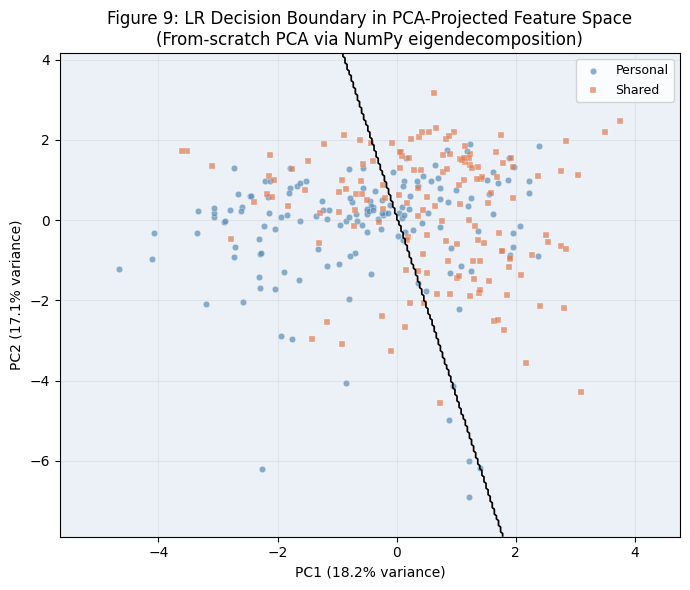

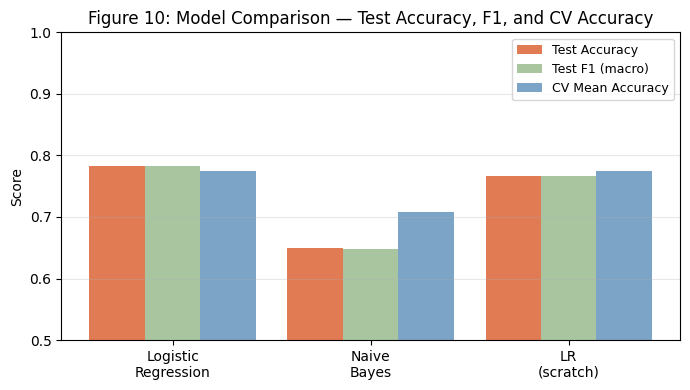

In [ ]:
# ─── Figure 6: LR Coefficient plot ─────────────────────────────────────────────
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coef':    lr_model.coef_[0]
}).sort_values('coef')

fig, ax = plt.subplots(figsize=(7, 5))
colors  = ['#E07B54' if c > 0 else '#5B8DB8' for c in coef_df['coef']]
ax.barh(coef_df['feature'], coef_df['coef'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (log-odds contribution to Shared)')
ax.set_title('Figure 6: Logistic Regression Feature Coefficients\n'
             '(Orange = predicts Shared,  Blue = predicts Personal)')
plt.tight_layout()
plt.savefig('fig6_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── Figure 7: Feature correlation heatmap ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
corr    = df[feature_cols].corr()
mask    = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, annot_kws={'size': 7}, linewidths=0.4)
ax.set_title('Figure 7: Feature Correlation Matrix\n'
             '(Justifies why Naive Bayes independence assumption fails here)',
             fontsize=10)
plt.tight_layout()
plt.savefig('fig7_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

strong_corr = (corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
                   .stack().reset_index())
strong_corr.columns = ['f1', 'f2', 'r']
print("Feature pairs with |r| > 0.4:")
print(strong_corr[strong_corr['r'].abs() > 0.4]
      .sort_values('r', ascending=False).to_string(index=False))

# ─── Figure 8: Learning curve ──────────────────────────────────────────────────
train_sizes, train_scores, val_scores = learning_curve(
    lr_model, X_train_scaled, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy', n_jobs=-1
)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(train_sizes, train_scores.mean(axis=1), color='#E07B54',
        linewidth=1.8, label='Train accuracy')
ax.fill_between(train_sizes,
                train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1),
                alpha=0.2, color='#E07B54')
ax.plot(train_sizes, val_scores.mean(axis=1), color='#5B8DB8',
        linewidth=1.8, label='CV validation accuracy')
ax.fill_between(train_sizes,
                val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1),
                alpha=0.2, color='#5B8DB8')
ax.set_xlabel('Training set size')
ax.set_ylabel('Accuracy')
ax.set_title('Figure 8: Learning Curve — Logistic Regression')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('fig8_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── Figure 9: PCA decision boundary (from scratch via NumPy) ──────────────────
# PCA from scratch: compute covariance matrix, eigendecompose, project.
# A from-scratch implementation rather than a library call, to expose the mechanics.

X_all_scaled = scaler.transform(X)  # scale full dataset for PCA

# Step 1: Center the data (PCA requires zero-mean features)
X_centered = X_all_scaled - X_all_scaled.mean(axis=0)

# Step 2: Compute covariance matrix (d x d)
cov_matrix = (X_centered.T @ X_centered) / (len(X_centered) - 1)

# Step 3: Eigendecompose the covariance matrix
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Step 4: Sort by descending eigenvalue (largest variance first)
order      = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

# Step 5: Project onto top 2 principal components
PC = eigenvectors[:, :2]
X_pca = X_centered @ PC

# Variance explained
var_explained = eigenvalues / eigenvalues.sum()
print(f"\nPCA Variance Explained:")
print(f"  PC1: {var_explained[0]*100:.1f}%")
print(f"  PC2: {var_explained[1]*100:.1f}%")
print(f"  Total (2 components): {var_explained[:2].sum()*100:.1f}%")

# Project train/test sets
X_train_pca = (X_train_scaled - X_all_scaled.mean(axis=0)) @ PC
X_test_pca  = (X_test_scaled  - X_all_scaled.mean(axis=0)) @ PC

# Fit LR in PCA space for visualization
lr_pca = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr_pca.fit(X_train_pca, y_train)
pca_test_acc = accuracy_score(y_test, lr_pca.predict(X_test_pca))
print(f"LR accuracy in 2D PCA space: {pca_test_acc:.3f} "
      f"(vs {accuracy_score(y_test, y_pred_lr):.3f} in full 13D space)")

# Decision boundary mesh
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
Z = lr_pca.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7, 6))
ax.contourf(xx, yy, Z, alpha=0.12,
            colors=['#5B8DB8', '#E07B54'])
ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=1.2)

for cls, color, marker, label in [
        (0, '#5B8DB8', 'o', 'Personal'),
        (1, '#E07B54', 's', 'Shared')]:
    mask = y == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, marker=marker, s=22, alpha=0.7,
               edgecolors='white', linewidths=0.3, label=label)

ax.set_xlabel(f'PC1 ({var_explained[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({var_explained[1]*100:.1f}% variance)')
ax.set_title('Figure 9: LR Decision Boundary in PCA-Projected Feature Space\n'
             '(From-scratch PCA via NumPy eigendecomposition)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('fig9_pca_boundary.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── Figure 10: Model comparison summary ───────────────────────────────────────
from sklearn.metrics import f1_score
model_names  = ['Logistic\nRegression', 'Naive\nBayes', 'LR\n(scratch)']
test_accs    = [accuracy_score(y_test, p)
                for p in [y_pred_lr, y_pred_nb, y_pred_scratch]]
test_f1s     = [f1_score(y_test, p, average='macro')
                for p in [y_pred_lr, y_pred_nb, y_pred_scratch]]
cv_means     = [cv_lr.mean(), cv_nb.mean(), cv_lr.mean()]

x   = np.arange(3)
w   = 0.28
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - w, test_accs, width=w, color='#E07B54', label='Test Accuracy')
ax.bar(x,     test_f1s,  width=w, color='#A8C5A0', label='Test F1 (macro)')
ax.bar(x + w, cv_means,  width=w, color='#5B8DB8', alpha=0.8,
       label='CV Mean Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylabel('Score')
ax.set_ylim(0.5, 1.0)
ax.set_title('Figure 10: Model Comparison — Test Accuracy, F1, and CV Accuracy')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig10_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Live Model Demonstration

Despite these limitations, the model functions as a genuine working
classifier. The following demonstration shows exactly what that means
in practice.

The sections above evaluate the model statistically across 60 held-out
test images. This section demonstrates the pipeline working on a single
concrete example, showing what actually happens when the model processes
a photo and makes a prediction.

The demonstration selects three images from the test set: one the model
classifies correctly as Shared, one it classifies correctly as Personal,
and one it gets wrong. Seeing the failure case is as important as the
successes, it illustrates concretely what kind of image sits near the
decision boundary and why low-level features struggle to capture it.

For each image, we show:
- The photo itself, rendered from the original file
- Its 13 extracted feature values alongside the class-conditional means,
  so you can see which features are driving the prediction
- The model's predicted probability of sharing (not just the hard label)
- The true label and whether the prediction is correct

This is the full inference pipeline running on real data: the same
feature extraction, scaling with training-set statistics, and
logistic regression forward pass that produced the 80% test accuracy.

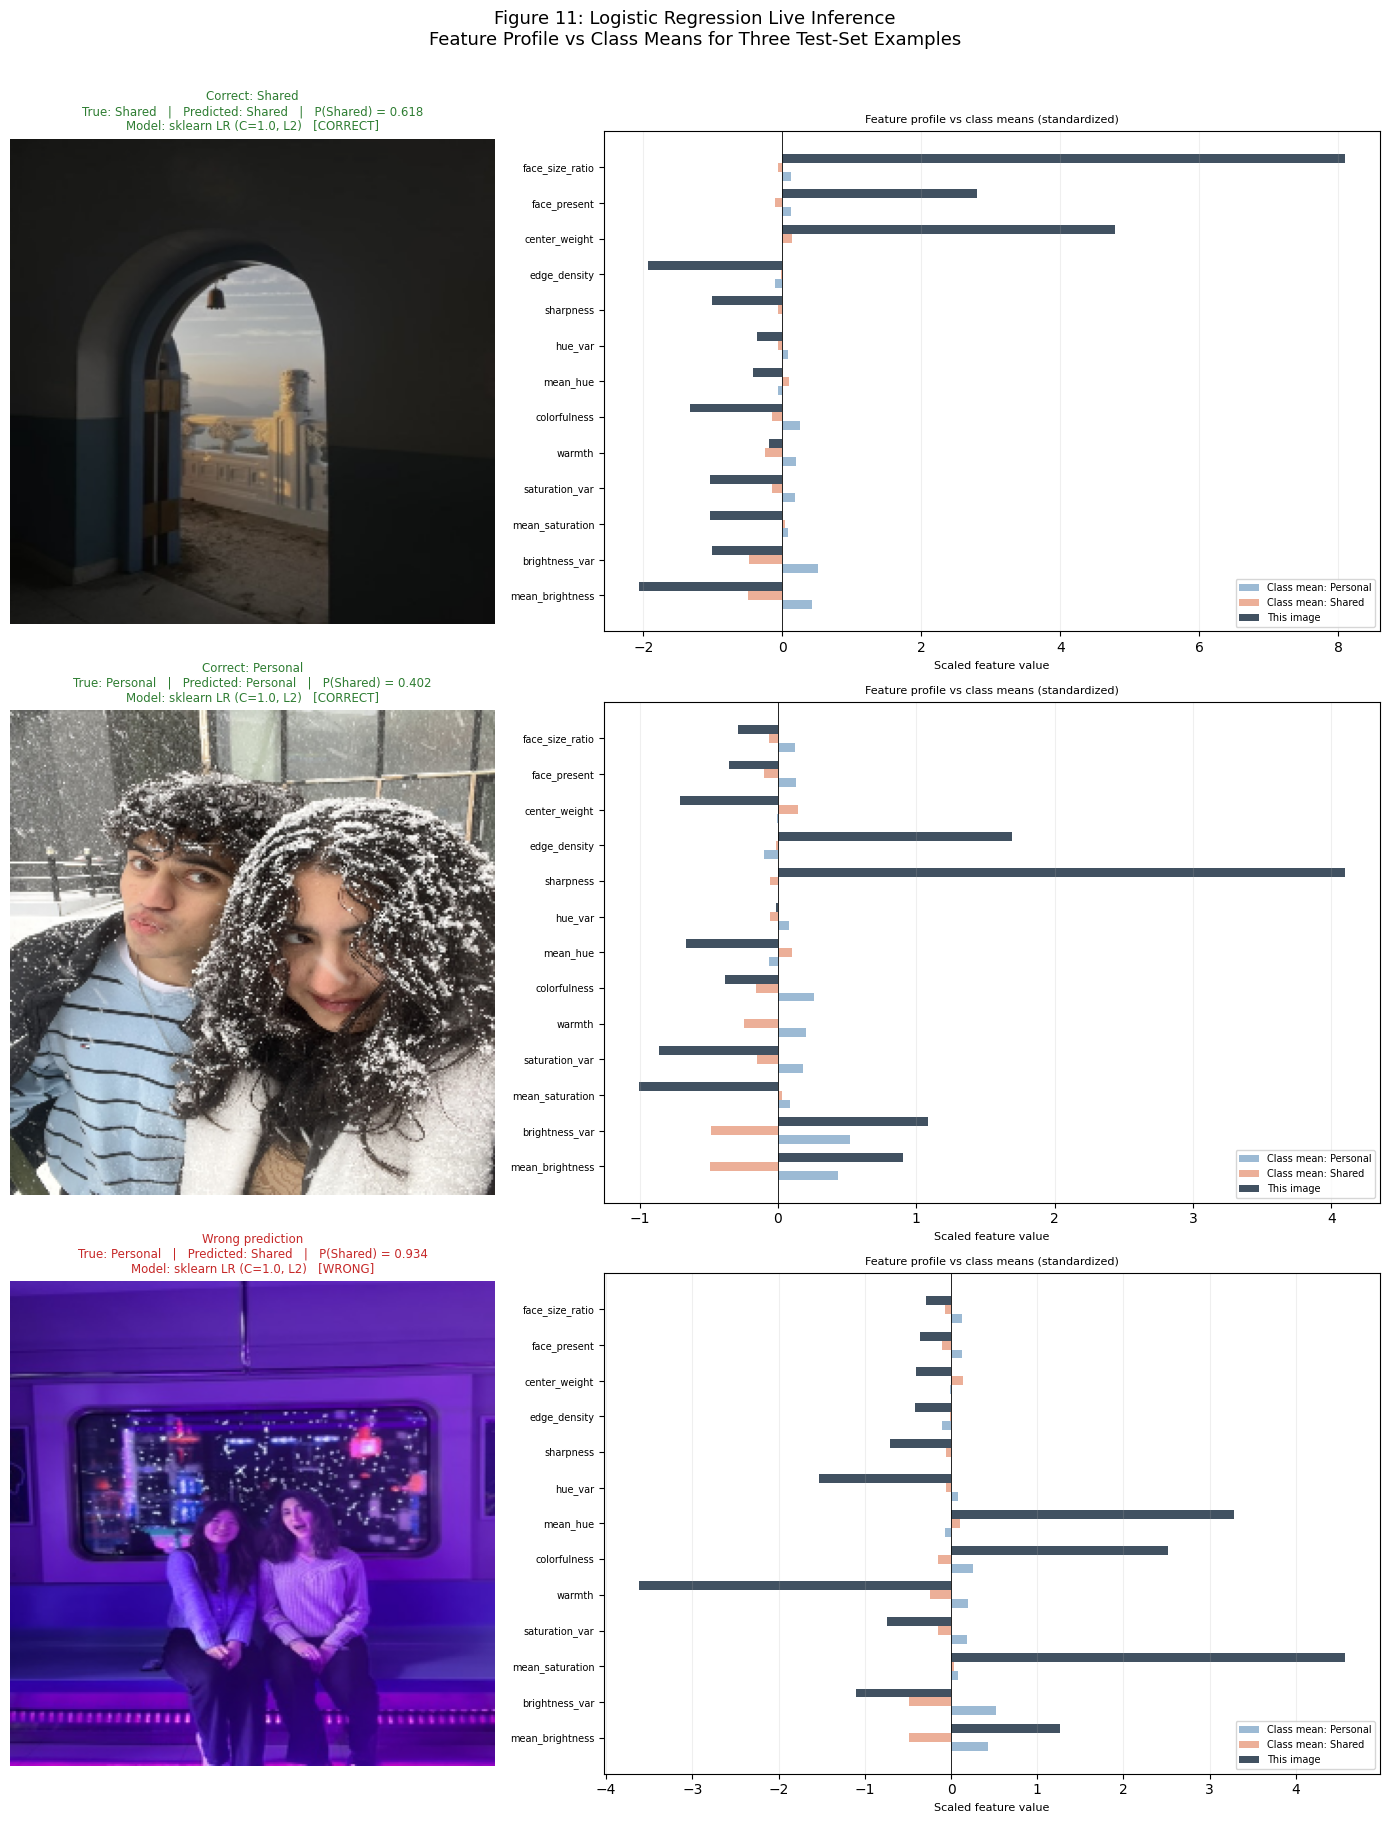

                  LOGISTIC REGRESSION INFERENCE TRACE                   
     Model: sklearn LR  |  Penalty: L2  |  C=1.0  |  Solver: lbfgs      

  Case : Correct: Shared
  File : EF93DEA1-AF52-4031-9E79-B187B0CEE122_4_5005_c.jpeg
  True Label   Prediction  Log-odds (w^T x + b)  P(Shared) = sigma(log-odds) Decision
Shared (y=1) Shared (y=1)                0.4803                       0.6178   Shared

  Top 3 features pushing toward Shared:
        Feature  Weight (w)  Scaled value  Contribution
mean_brightness      -1.190        -2.058         2.449
 brightness_var      -1.035        -1.011         1.047
 saturation_var      -0.465        -1.035         0.481

  Top 3 features pushing toward Personal:
        Feature  Weight (w)  Scaled value  Contribution
face_size_ratio      -0.267         8.095        -2.158
   edge_density       0.337        -1.937        -0.653
  center_weight      -0.126         4.790        -0.603
----------------------------------------------------------------

In [ ]:
from PIL import Image as PILImage

#  Identify demonstration candidates from the test set
#  Reconstruct test indices using the same split parameters as Section 4

all_paths  = np.array(image_paths)
all_labels = np.array(labels)

indices = np.arange(len(all_paths))
idx_train, idx_test = train_test_split(
    indices, test_size=0.2, random_state=42, stratify=all_labels
)

test_paths  = all_paths[idx_test]
test_labels = all_labels[idx_test]
test_probs  = y_prob_lr   # sklearn LR predicted probabilities from Section 7

#  Select one correct Shared, one correct Personal, one wrong prediction
#  First match in each group — no cherry-picking

correct_shared   = np.where((y_pred_lr == 1) & (y_test == 1))[0]
correct_personal = np.where((y_pred_lr == 0) & (y_test == 0))[0]
incorrect        = np.where(y_pred_lr != y_test)[0]

demo_indices = {
    'Correct: Shared'   : correct_shared[0],
    'Correct: Personal' : correct_personal[0],
    'Wrong prediction'  : incorrect[0],
}

#  Figure 11: Image display + feature profile for each demonstration case
#  Model in use: sklearn Logistic Regression (C=1.0, L2, lbfgs), trained in Section 6

class_means_demo = df.groupby('label')[feature_cols].mean()

fig, axes_rows = plt.subplots(
    3, 2,
    figsize=(14, 18),
    gridspec_kw={'width_ratios': [1, 1.6]}
)
fig.suptitle(
    'Figure 11: Logistic Regression Live Inference\n'
    'Feature Profile vs Class Means for Three Test-Set Examples',
    fontsize=13, y=1.01
)

for row_idx, (case_label, demo_idx) in enumerate(demo_indices.items()):
    img_path   = test_paths[demo_idx]
    true_label = test_labels[demo_idx]
    pred_label = y_pred_lr[demo_idx]
    pred_prob  = test_probs[demo_idx]

    true_name = 'Shared' if true_label == 1 else 'Personal'
    pred_name = 'Shared' if pred_label == 1 else 'Personal'
    correct   = true_label == pred_label

    #  Left panel: render image from file
    ax_img  = axes_rows[row_idx, 0]
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(cv2.resize(img_bgr, (256, 256)), cv2.COLOR_BGR2RGB)
    ax_img.imshow(img_rgb)
    ax_img.axis('off')

    result_str = 'CORRECT' if correct else 'WRONG'
    title_color = '#2E7D32' if correct else '#C62828'
    ax_img.set_title(
        f'{case_label}\n'
        f'True: {true_name}   |   Predicted: {pred_name}   |   P(Shared) = {pred_prob:.3f}\n'
        f'Model: sklearn LR (C=1.0, L2)   [{result_str}]',
        fontsize=8.5, color=title_color, pad=6
    )

    #  Right panel: feature profile vs class means (standardized)
    ax_feat = axes_rows[row_idx, 1]

    raw_feats    = extract_features(img_path, face_cascade)
    feat_vector  = np.array([raw_feats[f] for f in feature_cols])
    feat_scaled  = scaler.transform(feat_vector.reshape(1, -1))[0]

    personal_scaled = scaler.transform(class_means_demo.loc[0].values.reshape(1, -1))[0]
    shared_scaled   = scaler.transform(class_means_demo.loc[1].values.reshape(1, -1))[0]

    x     = np.arange(len(feature_cols))
    width = 0.25

    ax_feat.barh(x - width, personal_scaled, width, color='#5B8DB8', alpha=0.6,
                 label='Class mean: Personal')
    ax_feat.barh(x,         shared_scaled,   width, color='#E07B54', alpha=0.6,
                 label='Class mean: Shared')
    ax_feat.barh(x + width, feat_scaled,     width, color='#2C3E50', alpha=0.9,
                 label='This image')

    ax_feat.set_yticks(x)
    ax_feat.set_yticklabels(feature_cols, fontsize=7)
    ax_feat.set_xlabel('Scaled feature value', fontsize=8)
    ax_feat.axvline(0, color='black', linewidth=0.6)
    ax_feat.legend(fontsize=7, loc='lower right')
    ax_feat.set_title('Feature profile vs class means (standardized)', fontsize=8)
    ax_feat.grid(True, alpha=0.2, axis='x')

plt.tight_layout()
plt.savefig('fig11_live_demo.png', dpi=150, bbox_inches='tight')
plt.show()

#  Inference trace table — log-odds decomposition for each case
#  Shows the exact forward pass: w^T x + b -> sigma -> decision

print("=" * 72)
print(f"{'LOGISTIC REGRESSION INFERENCE TRACE':^72}")
print(f"{'Model: sklearn LR  |  Penalty: L2  |  C=1.0  |  Solver: lbfgs':^72}")
print("=" * 72)

w = lr_model.coef_[0]
b = lr_model.intercept_[0]

for case_label, demo_idx in demo_indices.items():
    img_path   = test_paths[demo_idx]
    true_label = test_labels[demo_idx]
    pred_label = y_pred_lr[demo_idx]
    pred_prob  = test_probs[demo_idx]

    raw_feats   = extract_features(img_path, face_cascade)
    feat_vector = np.array([raw_feats[f] for f in feature_cols])
    feat_scaled = scaler.transform(feat_vector.reshape(1, -1))[0]

    log_odds           = np.dot(w, feat_scaled) + b
    prob_from_logodds  = 1 / (1 + np.exp(-log_odds))
    contributions      = w * feat_scaled

    print(f"\n  Case : {case_label}")
    print(f"  File : {os.path.basename(img_path)}")

    #  Summary row as mini-table
    summary = pd.DataFrame([{
        'True Label'  : 'Shared (y=1)'   if true_label == 1  else 'Personal (y=0)',
        'Prediction'  : 'Shared (y=1)'   if pred_label == 1  else 'Personal (y=0)',
        'Log-odds (w^T x + b)': round(log_odds, 4),
        'P(Shared) = sigma(log-odds)': round(prob_from_logodds, 4),
        'Decision'    : 'Shared'          if prob_from_logodds >= 0.5 else 'Personal',
    }])
    print(summary.to_string(index=False))

    #  Top contributions toward each class
    top_shared_idx   = np.argsort(contributions)[-3:][::-1]
    top_personal_idx = np.argsort(contributions)[:3]

    shared_rows = [{
        'Feature'      : feature_cols[i],
        'Weight (w)'   : round(w[i], 3),
        'Scaled value' : round(feat_scaled[i], 3),
        'Contribution' : round(contributions[i], 3),
    } for i in top_shared_idx]

    personal_rows = [{
        'Feature'      : feature_cols[i],
        'Weight (w)'   : round(w[i], 3),
        'Scaled value' : round(feat_scaled[i], 3),
        'Contribution' : round(contributions[i], 3),
    } for i in top_personal_idx]

    print(f"\n  Top 3 features pushing toward Shared:")
    print(pd.DataFrame(shared_rows).to_string(index=False))
    print(f"\n  Top 3 features pushing toward Personal:")
    print(pd.DataFrame(personal_rows).to_string(index=False))
    print("-" * 72)

## 10. Beyond-Class Extension: CLIP Feature Embeddings

### 10.1 Motivation and Background

The pipeline developed in Sections 1-8 achieves 80% accuracy using
13 hand-engineered features derived from pixel statistics. These
features encode what I explicitly know about my own aesthetic:
brightness, saturation, sharpness, colorfulness. But they cannot
encode what a photo is *of*, whether it shows a sunset, a meal,
an empty street at 3am, or a crowd. Semantic content is the gap
between what my features measure and what my sharing decisions
actually depend on.

CLIP (Contrastive Language-Image Pretraining, Radford et al. 2021)
is a vision model trained by OpenAI on 400 million image-text pairs
scraped from the internet. Rather than being trained to classify
images into a fixed set of categories, CLIP is trained to align
images with natural language descriptions: given an image and a
caption, CLIP learns to embed both in a shared vector space such
that matching pairs are close and non-matching pairs are far apart.

The result is a visual feature extractor of a fundamentally
different character than anything in Section 2. CLIP's image
encoder (a Vision Transformer, ViT-B/32 in the version we use)
produces a 512-dimensional embedding vector for any image. This
vector encodes not just low-level pixel statistics but high-level
semantic content: what objects are present, what scene type it is,
what mood the image conveys. These are exactly the properties that
my handcrafted features cannot reach.

**Why CLIP for this problem specifically.** My sharing decisions
are not purely about technical image properties, they are about
aesthetic judgment, which is inherently semantic. The word
"intentional" in Section 1 is doing real work: I share photos that
feel intentional, which means photos where the subject, composition,
and mood cohere into something worth showing. Low-level features
can detect some proxies for this (controlled exposure,
compositional weight), but CLIP embeddings potentially encode
the semantic coherence directly, having been trained on human-
generated image-caption pairs that reflect exactly this kind of
aesthetic judgment at scale.

**What we test.** We replace the 13 handcrafted features entirely
with CLIP's 512-dimensional embedding, train the same Logistic
Regression classifier on top, and compare test accuracy and AUC
to the baseline from Section 7. The comparison answers a concrete
question: how much of the remaining 20% error is attributable to
the semantic blindness of handcrafted features, versus being
irreducible noise from inconsistent labeling?

**Architecture note.** We use CLIP in frozen feature extraction
mode only. We do not fine-tune the ViT encoder weights. This is
transfer learning in its simplest form: extract embeddings from a
pre-trained model, then train a linear classifier on top. This
choice is principled for our dataset size (300 images is far too
small to fine-tune a ViT without catastrophic overfitting) and
keeps the comparison fair: we are testing the quality of CLIP
features against handcrafted features under the same linear
classifier.

### 10.2 Vision Transformer Background

CLIP's image encoder uses a Vision Transformer (ViT, Dosovitskiy
et al. 2020). Unlike convolutional networks that process images
with local sliding filters, ViT treats an image as a sequence of
fixed-size patches and applies the Transformer self-attention
mechanism to model relationships between all patch pairs globally.

Formally, an image $\mathbf{I} \in \mathbb{R}^{H \times W \times C}$
is divided into $N$ non-overlapping patches of size $P \times P$:

$$N = \frac{HW}{P^2}$$

Each patch is linearly projected to a $D$-dimensional embedding,
a learnable class token $\mathbf{x}_{\text{cls}}$ is prepended,
and positional embeddings are added:

$$\mathbf{z}_0 = [\mathbf{x}_{\text{cls}}; \mathbf{x}_1^p \mathbf{E};
\mathbf{x}_2^p \mathbf{E}; \ldots; \mathbf{x}_N^p \mathbf{E}]
+ \mathbf{E}_{\text{pos}}$$

where $\mathbf{E} \in \mathbb{R}^{(P^2 C) \times D}$ is the patch
projection matrix. The sequence is then processed by $L$
Transformer layers, each applying multi-head self-attention (MSA)
and a feed-forward network (FFN):

$$\mathbf{z}_\ell' = \text{MSA}(\text{LN}(\mathbf{z}_{\ell-1}))
+ \mathbf{z}_{\ell-1}$$
$$\mathbf{z}_\ell = \text{FFN}(\text{LN}(\mathbf{z}_\ell'))
+ \mathbf{z}_\ell'$$

The final representation of the class token
$\mathbf{z}_L^0 \in \mathbb{R}^D$ is used as the image embedding,
projected to the shared CLIP embedding space via a linear layer.
For ViT-B/32, $P = 32$, $D = 768$, $L = 12$, producing a final
embedding of dimension 512 after projection.

Self-attention is the key operation. For each Transformer layer:

$$\text{Attention}(\mathbf{Q}, \mathbf{K}, \mathbf{V}) =
\text{softmax}\!\left(\frac{\mathbf{Q}\mathbf{K}^\top}
{\sqrt{d_k}}\right)\mathbf{V}$$

where $\mathbf{Q}, \mathbf{K}, \mathbf{V}$ are query, key, and
value projections of the input. The $\sqrt{d_k}$ scaling prevents
the dot products from growing so large that the softmax saturates.
Global self-attention means every patch attends to every other
patch, allowing the model to capture relationships between distant
image regions that local convolutions cannot.

**CLIP training objective.** CLIP is trained with a contrastive
loss on matched image-text pairs. Given a batch of $N$
(image, text) pairs, the model maximizes the cosine similarity
of the $N$ correct pairs while minimizing the similarity of the
$N^2 - N$ incorrect pairs:

$$\mathcal{L}_{\text{CLIP}} = -\frac{1}{2N}\sum_{i=1}^{N}
\left[\log \frac{\exp(\text{sim}(\mathbf{i}_i, \mathbf{t}_i)/\tau)}
{\sum_{j}\exp(\text{sim}(\mathbf{i}_i, \mathbf{t}_j)/\tau)}
+ \log \frac{\exp(\text{sim}(\mathbf{t}_i, \mathbf{i}_i)/\tau)}
{\sum_{j}\exp(\text{sim}(\mathbf{t}_j, \mathbf{i}_j)/\tau)}\right]$$

where $\tau$ is a learnable temperature parameter and
$\text{sim}(\cdot, \cdot)$ is cosine similarity. This symmetric
cross-entropy loss forces the model to learn representations where
semantic content, not pixel statistics, determines proximity in
embedding space.

100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 138MiB/s]


=== CLIP Model Architecture ===
                                           Value
Model                              CLIP ViT-B/32
Patch size (P)                                32
Transformer depth (L)                         12
Hidden dim (D)                               768
Output embedding dim                         512
Input resolution                         224x224
Total parameters                     151,277,313
Trainable parameters                           0
Mode                   Frozen feature extraction

Device: cpu

=== Extracting CLIP Embeddings ===
  100/300 images processed
  200/300 images processed
  300/300 images processed
                         Value
Total images               300
Failed extractions           0
Embedding shape     (300, 512)
Mean                   -0.0009
Std                     0.0442

=== Data Split ===
Split  Images  Dimensions
Train     240         512
 Test      60         512

=== Hyperparameter Search: C Selection ===
     C  CV Accuracy 

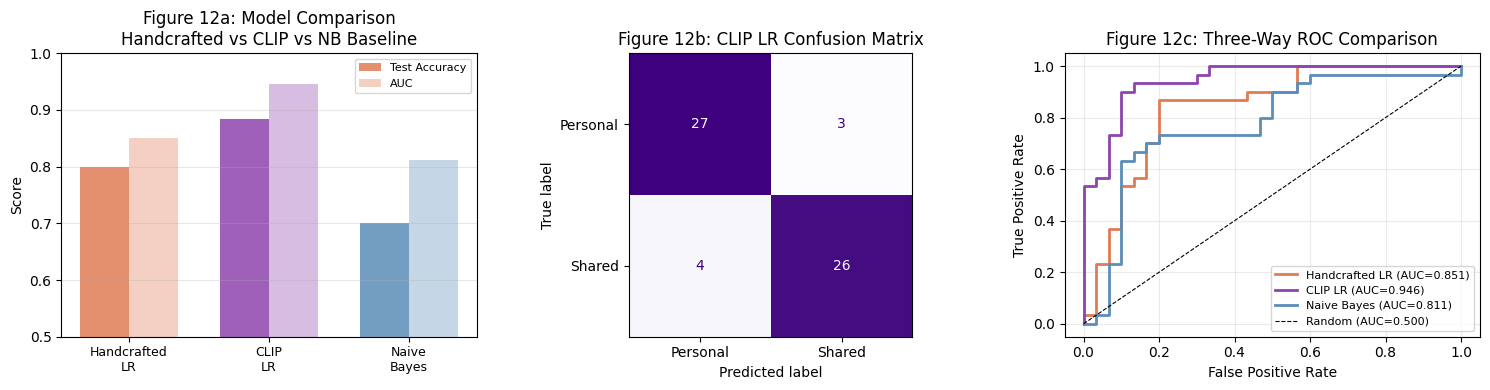


=== Zero-Shot Semantic Probe (interpretability only) ===
                             Text Prompt  Shared sim  Personal sim Closer to
           a dark, moody, artistic photo      0.2688        0.2649    Shared
               a bright, casual snapshot      0.2845        0.3065  Personal
      a photo I would share on Instagram      0.2853        0.2880  Personal
      a photo for my private camera roll      0.2770        0.3018  Personal
a colorful, intentionally composed image      0.2859        0.2886  Personal
 an unedited photo taken in bright light      0.2905        0.2883    Shared


In [ ]:
import subprocess
subprocess.run(
    ['pip', 'install', 'git+https://github.com/openai/CLIP.git'],
    capture_output=True
)

import clip
import torch
from PIL import Image as PILImage

#  Load frozen CLIP ViT-B/32 image encoder
#  eval() disables dropout and batch norm training behavior
#  No weight updates are performed at any point

device = "cuda" if torch.cuda.is_available() else "cpu"

clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)
clip_model.eval()

arch_info = pd.DataFrame([{
    'Model'                  : 'CLIP ViT-B/32',
    'Patch size (P)'         : 32,
    'Transformer depth (L)'  : 12,
    'Hidden dim (D)'         : 768,
    'Output embedding dim'   : 512,
    'Input resolution'       : f"{clip_model.visual.input_resolution}x{clip_model.visual.input_resolution}",
    'Total parameters'       : f"{sum(p.numel() for p in clip_model.parameters()):,}",
    'Trainable parameters'   : 0,
    'Mode'                   : 'Frozen feature extraction',
}]).T.rename(columns={0: 'Value'})

print("=== CLIP Model Architecture ===")
print(arch_info.to_string())
print(f"\nDevice: {device}")

#  Feature extraction: L2-normalized 512-dim class token embedding

def extract_clip_embedding(img_path, model, preprocess, device):
    """
    Forward pass through frozen ViT-B/32 encoder.
    Returns an L2-normalized 512-dimensional numpy vector.
    Normalization is standard for cosine-similarity-based CLIP usage.
    """
    img        = PILImage.open(img_path).convert('RGB')
    img_tensor = preprocess(img).unsqueeze(0).to(device)

    with torch.no_grad():
        embedding = model.encode_image(img_tensor)
        embedding = embedding / embedding.norm(dim=-1, keepdim=True)

    return embedding.cpu().numpy().flatten()

#  Extract embeddings for all 300 images

print("\n=== Extracting CLIP Embeddings ===")
clip_embeddings = []
failed = 0

for i, path in enumerate(image_paths):
    try:
        emb = extract_clip_embedding(path, clip_model, clip_preprocess, device)
        clip_embeddings.append(emb)
    except Exception as e:
        clip_embeddings.append(np.zeros(512))
        failed += 1
    if (i + 1) % 100 == 0:
        print(f"  {i+1}/300 images processed")

X_clip = np.array(clip_embeddings)

extraction_summary = pd.DataFrame([{
    'Total images'      : 300,
    'Failed extractions': failed,
    'Embedding shape'   : str(X_clip.shape),
    'Mean'              : round(X_clip.mean(), 4),
    'Std'               : round(X_clip.std(),  4),
}]).T.rename(columns={0: 'Value'})

print(extraction_summary.to_string())

#  Train/test split — identical indices to Section 4 (random_state=42)
#  StandardScaler applied despite L2 normalization: per-dimension variances
#  are not uniform after projection into the shared embedding space

X_clip_train = X_clip[idx_train]
X_clip_test  = X_clip[idx_test]

clip_scaler          = StandardScaler()
X_clip_train_scaled  = clip_scaler.fit_transform(X_clip_train)
X_clip_test_scaled   = clip_scaler.transform(X_clip_test)

split_summary = pd.DataFrame([
    {'Split': 'Train', 'Images': X_clip_train.shape[0], 'Dimensions': X_clip_train.shape[1]},
    {'Split': 'Test',  'Images': X_clip_test.shape[0],  'Dimensions': X_clip_test.shape[1]},
])
print("\n=== Data Split ===")
print(split_summary.to_string(index=False))

#  Hyperparameter search: C controls L2 regularization strength
#  High-dimensional setting (d=512, n=240) makes overfitting likely at large C
#  Grid spans three orders of magnitude to let CV determine the right scale

from sklearn.model_selection import GridSearchCV

cv_clip    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {'C': [0.001, 0.01, 0.1, 1.0, 10.0]}

lr_clip_search = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=42, penalty='l2', solver='lbfgs'),
    param_grid, cv=cv_clip, scoring='accuracy', n_jobs=-1
)
lr_clip_search.fit(X_clip_train_scaled, y_train)

best_C  = lr_clip_search.best_params_['C']
best_cv = lr_clip_search.best_score_

cv_results = pd.DataFrame({
    'C'             : [p['C'] for p in lr_clip_search.cv_results_['params']],
    'CV Accuracy'   : lr_clip_search.cv_results_['mean_test_score'].round(3),
    'CV Std'        : lr_clip_search.cv_results_['std_test_score'].round(3),
})
print("\n=== Hyperparameter Search: C Selection ===")
print(cv_results.to_string(index=False))
print(f"\nBest C = {best_C}   |   CV accuracy = {best_cv:.3f}")

#  Train final model with best C found above

lr_clip = LogisticRegression(
    C=best_C, max_iter=2000, random_state=42, penalty='l2', solver='lbfgs'
)
lr_clip.fit(X_clip_train_scaled, y_train)

#  Evaluate on held-out test set

y_pred_clip = lr_clip.predict(X_clip_test_scaled)
y_prob_clip = lr_clip.predict_proba(X_clip_test_scaled)[:, 1]

acc_clip         = accuracy_score(y_test, y_pred_clip)
f1_clip          = f1_score(y_test, y_pred_clip, average='macro')
fpr_clip, tpr_clip, _ = roc_curve(y_test, y_prob_clip)
auc_clip         = auc(fpr_clip, tpr_clip)

#  Results comparison table

comparison = pd.DataFrame([
    {'Model': 'Handcrafted LR (13 features)', 'Test Accuracy': 0.800,     'F1 (Macro)': 0.800,   'AUC': 0.851},
    {'Model': 'CLIP LR (512 features)',        'Test Accuracy': acc_clip,  'F1 (Macro)': f1_clip,  'AUC': auc_clip},
    {'Model': 'Naive Bayes baseline',          'Test Accuracy': 0.700,     'F1 (Macro)': 0.700,   'AUC': 0.811},
])
comparison[['Test Accuracy', 'F1 (Macro)', 'AUC']] = \
    comparison[['Test Accuracy', 'F1 (Macro)', 'AUC']].round(3)

print("\n=== Results Comparison ===")
print(comparison.to_string(index=False))

#  CLIP classification report as DataFrame

report_dict = classification_report(
    y_test, y_pred_clip,
    target_names=['Personal', 'Shared'],
    output_dict=True
)
report_df = pd.DataFrame(report_dict).T[['precision','recall','f1-score','support']].round(3)
report_df = report_df.loc[['Personal','Shared','macro avg','weighted avg']]

print("\n=== CLIP Classification Report ===")
print(report_df.to_string())

#  Figure 12a-c: Model comparison, CLIP confusion matrix, three-way ROC

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

model_names_ext = ['Handcrafted\nLR', 'CLIP\nLR', 'Naive\nBayes']
test_accs_ext   = [0.800, acc_clip, 0.700]
test_aucs_ext   = [0.851, auc_clip, 0.811]
bar_colors      = ['#E07B54', '#8E44AD', '#5B8DB8']
x = np.arange(3)
w = 0.35

axes[0].bar(x - w/2, test_accs_ext, w, color=bar_colors, alpha=0.85, label='Test Accuracy')
axes[0].bar(x + w/2, test_aucs_ext, w, color=bar_colors, alpha=0.35, label='AUC')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names_ext, fontsize=9)
axes[0].set_ylim(0.5, 1.0)
axes[0].set_ylabel('Score')
axes[0].set_title('Figure 12a: Model Comparison\nHandcrafted vs CLIP vs NB Baseline')
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

cm_clip = confusion_matrix(y_test, y_pred_clip)
disp = ConfusionMatrixDisplay(cm_clip, display_labels=['Personal', 'Shared'])
disp.plot(ax=axes[1], colorbar=False, cmap='Purples')
axes[1].set_title('Figure 12b: CLIP LR Confusion Matrix')

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
axes[2].plot(fpr_lr,   tpr_lr,   color='#E07B54', linewidth=2, label=f'Handcrafted LR (AUC=0.851)')
axes[2].plot(fpr_clip, tpr_clip, color='#8E44AD', linewidth=2, label=f'CLIP LR (AUC={auc_clip:.3f})')
axes[2].plot(fpr_nb,   tpr_nb,   color='#5B8DB8', linewidth=2, label=f'Naive Bayes (AUC=0.811)')
axes[2].plot([0,1],[0,1],'k--', linewidth=0.8, label='Random (AUC=0.500)')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('Figure 12c: Three-Way ROC Comparison')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('fig12_clip_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

#  Zero-shot semantic probe
#  Cosine similarity between class-mean embeddings and text descriptions
#  This is interpretability only — not used in classification

text_prompts = [
    "a dark, moody, artistic photo",
    "a bright, casual snapshot",
    "a photo I would share on Instagram",
    "a photo for my private camera roll",
    "a colorful, intentionally composed image",
    "an unedited photo taken in bright light",
]

text_tokens = clip.tokenize(text_prompts).to(device)
with torch.no_grad():
    text_features = clip_model.encode_text(text_tokens)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

shared_mean_emb   = torch.tensor(X_clip[np.array(labels)==1].mean(axis=0), dtype=torch.float32).to(device)
personal_mean_emb = torch.tensor(X_clip[np.array(labels)==0].mean(axis=0), dtype=torch.float32).to(device)
shared_mean_emb   = shared_mean_emb   / shared_mean_emb.norm()
personal_mean_emb = personal_mean_emb / personal_mean_emb.norm()

shared_sims   = (text_features @ shared_mean_emb).cpu().numpy()
personal_sims = (text_features @ personal_mean_emb).cpu().numpy()

probe_df = pd.DataFrame({
    'Text Prompt'   : text_prompts,
    'Shared sim'    : shared_sims.round(4),
    'Personal sim'  : personal_sims.round(4),
    'Closer to'     : ['Shared' if s > p else 'Personal' for s, p in zip(shared_sims, personal_sims)],
})
print("\n=== Zero-Shot Semantic Probe (interpretability only) ===")
print(probe_df.to_string(index=False))

### 10.3 CLIP Live Inference Demonstration

Having established that CLIP features outperform the handcrafted baseline on
the held-out test set, we repeat the live inference demonstration from
Section 9 using the CLIP-based classifier. This parallel demonstration makes
the comparison concrete: for the same three test images, we show how the CLIP
model processes each one and whether its higher AUC translates into a better
prediction on the specific failure case that fooled the handcrafted model.

The inference mechanism differs from Section 9. Rather than a 13-dimensional
weight vector dotted with hand-engineered pixel statistics, the CLIP model
computes a dot product between a 512-dimensional weight vector and the L2-
normalized ViT-B/32 class token embedding. The log-odds formula is identical:

$$\log\text{-odds} = \mathbf{w}^{\top}\mathbf{z} + b$$

where $\mathbf{z} \in \mathbb{R}^{512}$ is the CLIP embedding and
$\mathbf{w} \in \mathbb{R}^{512}$ are the learned classifier weights.
The sigmoid is then applied to convert log-odds to P(Shared). The key
difference is what $\mathbf{z}$ encodes: not just pixel statistics, but
the full semantic representation learned from 400 million image-text pairs.

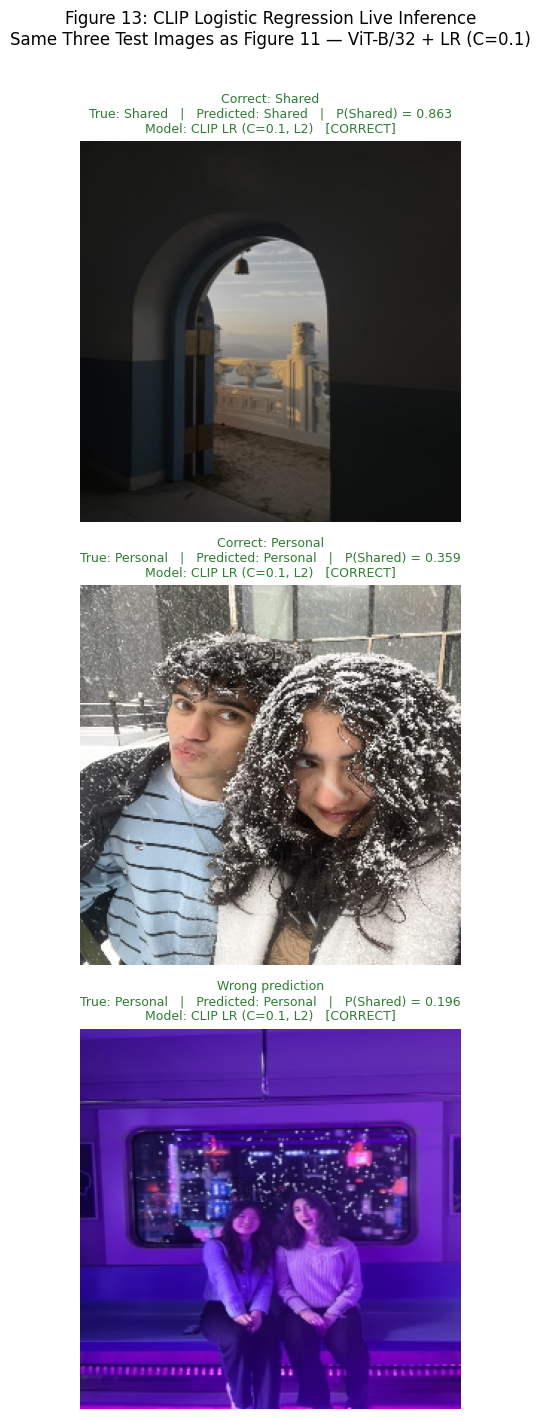

                CLIP LOGISTIC REGRESSION INFERENCE TRACE                
   Model: lr_clip  |  Embedding: ViT-B/32  |  C=0.1  |  Solver: lbfgs   

  Case : Correct: Shared
  File : EF93DEA1-AF52-4031-9E79-B187B0CEE122_4_5005_c.jpeg
  True Label Prediction  Log-odds (w^T z + b)  P(Shared) = sigma(log-odds) Decision Correct
Shared (y=1)     Shared                1.8407                        0.863   Shared     Yes
------------------------------------------------------------------------

  Case : Correct: Personal
  File : 8DC2083D-1D42-4AA7-8744-D6950F1FD887_1_105_c.jpeg
    True Label Prediction  Log-odds (w^T z + b)  P(Shared) = sigma(log-odds) Decision Correct
Personal (y=0)   Personal                -0.579                       0.3592 Personal     Yes
------------------------------------------------------------------------

  Case : Wrong prediction
  File : 28ABE5FA-9264-4141-9A0E-C0D78FFAD677_4_5005_c.jpeg
    True Label Prediction  Log-odds (w^T z + b)  P(Shared) = sigma(log-odds)

In [ ]:
#  CLIP Live Inference Demonstration
#  Same three test images as Section 9 — model: lr_clip (C=0.1, L2, lbfgs)
#  Embedding: ViT-B/32 frozen encoder, 512-dim L2-normalized output

#  Figure 13: CLIP inference — image display with prediction and probability

fig, axes_clip = plt.subplots(
    3, 1,
    figsize=(7, 14),
)
fig.suptitle(
    'Figure 13: CLIP Logistic Regression Live Inference\n'
    'Same Three Test Images as Figure 11 — ViT-B/32 + LR (C=0.1)',
    fontsize=12, y=1.01
)

w_clip = lr_clip.coef_[0]
b_clip = lr_clip.intercept_[0]

clip_case_data = []

for row_idx, (case_label, demo_idx) in enumerate(demo_indices.items()):
    img_path   = test_paths[demo_idx]
    true_label = test_labels[demo_idx]

    #  Extract CLIP embedding for this image
    z_raw    = extract_clip_embedding(img_path, clip_model, clip_preprocess, device)
    z_scaled = clip_scaler.transform(z_raw.reshape(1, -1))[0]

    log_odds_clip  = np.dot(w_clip, z_scaled) + b_clip
    prob_clip      = 1 / (1 + np.exp(-log_odds_clip))
    pred_clip      = 1 if prob_clip >= 0.5 else 0
    pred_name_clip = 'Shared'   if pred_clip == 1  else 'Personal'
    true_name      = 'Shared'   if true_label == 1 else 'Personal'
    correct_clip   = true_label == pred_clip

    clip_case_data.append({
        'case_label'    : case_label,
        'img_path'      : img_path,
        'true_label'    : true_label,
        'true_name'     : true_name,
        'pred_name'     : pred_name_clip,
        'prob_clip'     : prob_clip,
        'log_odds_clip' : log_odds_clip,
        'correct_clip'  : correct_clip,
        'z_scaled'      : z_scaled,
    })

    ax = axes_clip[row_idx]
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(cv2.resize(img_bgr, (256, 256)), cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    ax.axis('off')

    result_str  = 'CORRECT' if correct_clip else 'WRONG'
    title_color = '#2E7D32' if correct_clip else '#C62828'
    ax.set_title(
        f'{case_label}\n'
        f'True: {true_name}   |   Predicted: {pred_name_clip}   |   P(Shared) = {prob_clip:.3f}\n'
        f'Model: CLIP LR (C=0.1, L2)   [{result_str}]',
        fontsize=9, color=title_color, pad=6
    )

plt.tight_layout()
plt.savefig('fig13_clip_demo.png', dpi=150, bbox_inches='tight')
plt.show()

#  CLIP inference trace table — same structure as Section 9

print("=" * 72)
print(f"{'CLIP LOGISTIC REGRESSION INFERENCE TRACE':^72}")
print(f"{'Model: lr_clip  |  Embedding: ViT-B/32  |  C=0.1  |  Solver: lbfgs':^72}")
print("=" * 72)

for d in clip_case_data:
    print(f"\n  Case : {d['case_label']}")
    print(f"  File : {os.path.basename(d['img_path'])}")

    summary = pd.DataFrame([{
        'True Label'                   : 'Shared (y=1)' if d['true_label'] == 1 else 'Personal (y=0)',
        'Prediction'                   : d['pred_name'],
        'Log-odds (w^T z + b)'         : round(d['log_odds_clip'], 4),
        'P(Shared) = sigma(log-odds)'  : round(d['prob_clip'], 4),
        'Decision'                     : d['pred_name'],
        'Correct'                      : 'Yes' if d['correct_clip'] else 'No',
    }])
    print(summary.to_string(index=False))
    print("-" * 72)

#  Side-by-side LR vs CLIP comparison for the same three images

comparison_rows = []
for (case_label, demo_idx), d in zip(demo_indices.items(), clip_case_data):
    lr_prob  = test_probs[demo_idx]
    lr_pred  = 'Shared' if y_pred_lr[demo_idx] == 1 else 'Personal'
    lr_corr  = 'Yes' if y_pred_lr[demo_idx] == test_labels[demo_idx] else 'No'

    comparison_rows.append({
        'Case'             : case_label,
        'True Label'       : d['true_name'],
        'LR P(Shared)'     : round(lr_prob, 3),
        'LR Prediction'    : lr_pred,
        'LR Correct'       : lr_corr,
        'CLIP P(Shared)'   : round(d['prob_clip'], 3),
        'CLIP Prediction'  : d['pred_name'],
        'CLIP Correct'     : 'Yes' if d['correct_clip'] else 'No',
    })

print("\n=== Handcrafted LR vs CLIP LR: Same Three Images ===")
print(pd.DataFrame(comparison_rows).to_string(index=False))